# Chapter 9. Manipulation of molecular structures
This chapter transitions from the theoretical representation of molecules to their practical, hands-on manipulation using Python. It serves as a foundational guide to the core computational chemistry operations that are prerequisite for nearly all advanced applications, from drug discovery to materials science. We begin with the essentials of working with molecular structures: reading them from various standard formats like SMILES and MOL files, generating 2D visualizations, editing their atomic composition, and writing them back to disk.
Building on this, the chapter explores the critical task of generating realistic 3D conformations, a necessary step for shape-based analysis. We then provide a comprehensive overview of calculating molecular descriptors and fingerprints—the numerical and binary vectors that translate chemical structures into a language suitable for machine learning. Following this, we address the concept of molecular similarity, demonstrating how to quantify the likeness between molecules, a cornerstone of virtual screening and lead optimization. The chapter also details methods for performing substructure and full structure searches to identify specific chemical motifs within large datasets. Finally, we introduce techniques for implementing chemical transformations and reactions, enabling the in-silico exploration of chemical synthesis and library enumeration. Throughout the chapter, practical examples using the RDKit library will empower readers to programmatically manage, analyze, and transform molecular data.

In [16]:
import os
OUTPUT_DIR = "output"
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

## 9.1 Working with molecular structures

### 9.1.1 Reading molecules

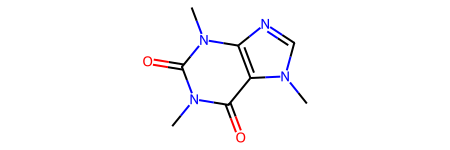

In [139]:
#
# Code Example 9.1.1: Loading a molecule from a SMILES string
#
from rdkit import Chem

# Define the SMILES string for caffeine
caffeine_smiles = "CN1C=NC2=C1C(=O)N(C(=O)N2C)C"

# Create a molecule object from the SMILES string
mol_caffeine = Chem.MolFromSmiles(caffeine_smiles)
# The 'mol_caffeine' variable now holds an RDKit molecule object

# Printing the object itself confirms its creation but is not a visual representation
# <rdkit.Chem.rdchem.Mol object at 0x...>
print(mol_caffeine)  # This will print the RDKit molecule object representation
mol_caffeine

In [140]:
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D

# Save the molecular structure of caffeine as an SVG file

# Create an SVG drawer
drawer = rdMolDraw2D.MolDraw2DSVG(400, 400)

# Draw the caffeine molecule
drawer.DrawMolecule(mol_caffeine)
drawer.FinishDrawing()

# Get the SVG string and save to file
svg_string = drawer.GetDrawingText()

# Save to SVG file
with open(f'{OUTPUT_DIR}/caffeine.svg', 'w') as f:
    f.write(svg_string)

print(f"Caffeine structure saved as '{OUTPUT_DIR}/caffeine.svg'")

Caffeine structure saved as 'output/caffeine.svg'


In [208]:
aspirin_mol_content = """2244
 OpenBabel06272514113D

 21 21  0  0  0  0  0  0  0  0999 V2000
    1.2333    0.5540    0.7792 O   0  0  0  0  0  0  0  0  0  0  0  0
   -0.6952   -2.7148   -0.7502 O   0  0  0  0  0  0  0  0  0  0  0  0
    0.7958   -2.1843    0.8685 O   0  0  0  0  0  0  0  0  0  0  0  0
    1.7813    0.8105   -1.4821 O   0  0  0  0  0  0  0  0  0  0  0  0
   -0.0857    0.6088    0.4403 C   0  0  0  0  0  0  0  0  0  0  0  0
   -0.7927   -0.5515    0.1244 C   0  0  0  0  0  0  0  0  0  0  0  0
   -0.7288    1.8464    0.4133 C   0  0  0  0  0  0  0  0  0  0  0  0
   -2.1426   -0.4741   -0.2184 C   0  0  0  0  0  0  0  0  0  0  0  0
   -2.0787    1.9238    0.0706 C   0  0  0  0  0  0  0  0  0  0  0  0
   -2.7855    0.7636   -0.2453 C   0  0  0  0  0  0  0  0  0  0  0  0
   -0.1409   -1.8536    0.1477 C   0  0  0  0  0  0  0  0  0  0  0  0
    2.1094    0.6715   -0.3113 C   0  0  0  0  0  0  0  0  0  0  0  0
    3.5305    0.5996    0.1635 C   0  0  0  0  0  0  0  0  0  0  0  0
   -0.1851    2.7545    0.6593 H   0  0  0  0  0  0  0  0  0  0  0  0
   -2.7247   -1.3605   -0.4564 H   0  0  0  0  0  0  0  0  0  0  0  0
   -2.5797    2.8872    0.0506 H   0  0  0  0  0  0  0  0  0  0  0  0
   -3.8374    0.8238   -0.5090 H   0  0  0  0  0  0  0  0  0  0  0  0
    3.7290    1.4184    0.8593 H   0  0  0  0  0  0  0  0  0  0  0  0
    4.2045    0.6969   -0.6924 H   0  0  0  0  0  0  0  0  0  0  0  0
    3.7105   -0.3659    0.6426 H   0  0  0  0  0  0  0  0  0  0  0  0
   -0.2555   -3.5916   -0.7337 H   0  0  0  0  0  0  0  0  0  0  0  0
  1  5  1  0  0  0  0
  1 12  1  0  0  0  0
  2 11  1  0  0  0  0
  2 21  1  0  0  0  0
  3 11  2  0  0  0  0
  4 12  2  0  0  0  0
  5  6  1  0  0  0  0
  5  7  2  0  0  0  0
  6  8  2  0  0  0  0
  6 11  1  0  0  0  0
  7  9  1  0  0  0  0
  7 14  1  0  0  0  0
  8 10  1  0  0  0  0
  8 15  1  0  0  0  0
  9 10  2  0  0  0  0
  9 16  1  0  0  0  0
 10 17  1  0  0  0  0
 12 13  1  0  0  0  0
 13 18  1  0  0  0  0
 13 19  1  0  0  0  0
 13 20  1  0  0  0  0
M  END
"""
with open(f'{OUTPUT_DIR}/aspirin.mol', 'w') as f:
    f.write(aspirin_mol_content)

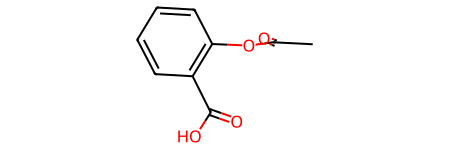

In [209]:
#
# Code Example 9.1.2: Loading a molecule from a MOL file
#
from rdkit import Chem

# Specify the path to the MOL file
mol_filepath = f"{OUTPUT_DIR}/aspirin.mol" # Assumes this file exists

# Create a molecule object by reading the MOL file
mol_aspirin = Chem.MolFromMolFile(mol_filepath)

mol_aspirin

In [142]:
#
# Code Example 9.1.3: Best practice for checking successful parsing
#
invalid_smiles = "C1(C)C" # An invalid SMILES string
mol = Chem.MolFromSmiles(invalid_smiles)

if mol is not None:
    # Proceed with analysis
    print("Molecule loaded successfully.")
else:
    # Handle the error gracefully
    print("Failed to parse the input SMILES.")

Failed to parse the input SMILES.


[21:45:26] SMILES Parse Error: unclosed ring for input: 'C1(C)C'


### 9.1.2 Drawing Molecules

In [143]:
#
# Code Example 9.1.4: Saving a 2D image of a single molecule
#
from rdkit import Chem
from rdkit.Chem import Draw

# Create a molecule object for benzene
benzene_smiles = "c1ccccc1"
benzene_mol = Chem.MolFromSmiles(benzene_smiles)

# Check for successful parsing before proceeding
if benzene_mol:
    # Generate and save the 2D image of benzene to a file
    Draw.MolToFile(benzene_mol, f"{OUTPUT_DIR}/benzene.png")

In [144]:
#
# Code Example 9.1.5: Generating a grid image of multiple molecules
#
from rdkit import Chem
from rdkit.Chem import Draw

# A list of SMILES strings for several common molecules
smiles_list = ["c1ccccc1", "CCO", "CC(=O)O", "C1=CC=CN=C1"]
mol_names = ["Benzene", "Ethanol", "Acetic Acid", "Pyridine"]

# Use a list comprehension to create molecule objects
# Note the check for None to handle potential parsing errors
mol_list = [Chem.MolFromSmiles(smi) for smi in smiles_list]
valid_mols = [m for m in mol_list if m is not None]
valid_legends = [mol_names[i] for i, m in enumerate(mol_list) if m is not None]

# Generate a grid image with 2 molecules per row
img = Draw.MolsToGridImage(
    valid_mols,
    molsPerRow=2,
    legends=valid_legends,
    returnPNG=False,
)

# Save the generated PIL Image object to a file
img.save(f"{OUTPUT_DIR}/molecule_grid.png")

### 9.1.3 Editing Molecules

Initial SMILES: C


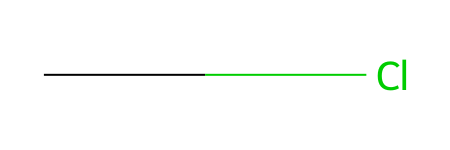

In [145]:
#
# Code Example 9.1.6: Editing a molecule using the RWMol class
#
from rdkit import Chem

# Step 1: Create a standard Mol object from a SMILES string
methane_mol = Chem.MolFromSmiles('C')
print(f"Initial SMILES: {Chem.MolToSmiles(methane_mol)}")

# Step 2: Convert the immutable Mol into a mutable RWMol object
rw_mol = Chem.RWMol(methane_mol)

# Step 3: Add a new atom.
# The AddAtom() method takes an Atom object and returns the index of the new atom.
cl_atom = Chem.Atom('Cl')
cl_index = rw_mol.AddAtom(cl_atom)
# At this point, the molecule contains a disconnected chlorine atom.

# Step 4: Add a new bond between the original carbon (index 0) and the new chlorine.
# The AddBond() method takes the indices of the two atoms and the bond type.
carbon_index = 0
rw_mol.AddBond(carbon_index, cl_index, Chem.BondType.SINGLE)

# Step 5: Finalize the molecule and convert back to a standard Mol object.
# It is often best to retrieve the final Mol object for further use.
chloromethane_mol = rw_mol.GetMol()
chloromethane_mol

In [146]:
#
# Code Example 9.1.7: Sanitizing and retrieving the final molecule
#
# Continuing from the previous example...
# Sanitize the molecule to update its chemical properties
Chem.SanitizeMol(chloromethane_mol)

# Verify the final structure by printing its SMILES
print(f"Final SMILES: {Chem.MolToSmiles(chloromethane_mol)}")
# Expected output: CCl (RDKit generate a canonical SMILES)

Final SMILES: CCl


### 9.1.4 Writing molecules

In [147]:
#
# Code Example 9.1.8: Converting a molecule object to a canonical SMILES string
#
from rdkit import Chem

# Create a molecule object for toluene from a non-canonical SMILES
# In this input, the methyl group is the first atom
mol = Chem.MolFromSmiles('c1ccccc1C')

# Convert the molecule object back to a canonical SMILES string
# RDKit's algorithm will generate a standardized representation
canonical_smiles = Chem.MolToSmiles(mol)

# The output is the canonical form, which may differ from the input
print(f"Input SMILES: c1ccccc1C")
print(f"Canonical SMILES: {canonical_smiles}")
# Expected output: Canonical SMILES: Cc1ccccc1

Input SMILES: c1ccccc1C
Canonical SMILES: Cc1ccccc1


In [148]:
#
# Code Example 9.1.9: Writing a molecule to a .mol file with 2D coordinates
#
from rdkit import Chem
from rdkit.Chem import AllChem

# Create a molecule object for Aspirin
aspirin_smiles = 'CC(=O)OC1=CC=CC=C1C(=O)O'
aspirin_mol = Chem.MolFromSmiles(aspirin_smiles)

# Generate 2D coordinates for the molecule object in place
AllChem.Compute2DCoords(aspirin_mol)

# Get the string representation of the MOL block
mol_block = Chem.MolToMolBlock(aspirin_mol)

# Write the MOL block string to a .mol file
with open(f'{OUTPUT_DIR}/aspirin_generated.mol', 'w') as f:
    f.write(mol_block)

print(f"'{OUTPUT_DIR}/aspirin_generated.mol' file has been created.")

'output/aspirin_generated.mol' file has been created.


In [149]:
#
# Code Example 9.1.10: Using SDWriter to save multiple molecules
#
from rdkit import Chem

smiles_list = ['CCO', 'c1ccccc1', 'CC(=O)O']
mols = [Chem.MolFromSmiles(smi) for smi in smiles_list]

# Initialize the writer with the output filename
writer = Chem.SDWriter(f'{OUTPUT_DIR}/compounds.sdf')

# Iterate through the molecule list and write each one
for mol in mols:
    if mol: # Always a good idea to check for valid molecules
        writer.write(mol)

# Close the writer to ensure all content is written to disk and the file is properly finalized
writer.close()
print(f"'{OUTPUT_DIR}/compounds.sdf' file has been created.")

'output/compounds.sdf' file has been created.


## 9.2 Conformer generation

### 9.2.1 Distance geometry

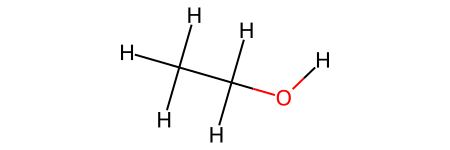

In [150]:
#
# Code Example 9.2.1: Generating a 3D conformer using Distance Geometry
#
from rdkit import Chem
from rdkit.Chem import AllChem

# 1. Create a molecule object from SMILES
mol = Chem.MolFromSmiles('CCO') # Ethanol

# 2. Add explicit hydrogens. This is essential for a realistic 3D model.
mol_with_hs = Chem.AddHs(mol)
mol_with_hs

In [151]:

# 3. Generate a 3D conformer. The function modifies the molecule object in place.
# It returns an integer status code: 0 for success, -1 for failure.
status = AllChem.EmbedMolecule(mol_with_hs)

# 4. Check the status and the number of conformers
if status == 0:
    print("3D conformer generated successfully.")
    # The conformer is now stored with the molecule object.
    # We can check how many conformers were generated (should be 1).
    print(f"Number of conformers: {mol_with_hs.GetNumConformers()}")
else:
    print("Conformer generation failed.")

# To access the conformer object itself:
conf = mol_with_hs.GetConformer(0)

3D conformer generated successfully.
Number of conformers: 1


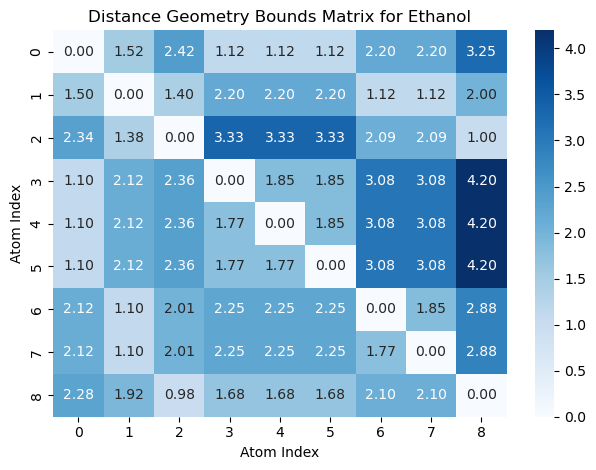

In [152]:
from rdkit import Chem
from rdkit.Chem import AllChem
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

mol = Chem.MolFromSmiles('CCO')
mol_with_hs = Chem.AddHs(mol)
bounds_matrix = AllChem.GetMoleculeBoundsMatrix(mol_with_hs)
sns.heatmap(bounds_matrix, annot=True, fmt=".2f", cmap="Blues")
plt.title('Distance Geometry Bounds Matrix for Ethanol')
plt.xlabel('Atom Index')
plt.ylabel('Atom Index')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/bounds_matrix.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()

In [153]:
from rdkit import Chem
from rdkit.Chem import AllChem

#
# Code Example 9.2.1a: Generating multiple conformers using Distance Geometry
#

# Use a more flexible molecule for multiple conformer generation
flexible_mol = Chem.MolFromSmiles('CCO')  # Ethanol - flexible molecule
flexible_mol_with_hs = Chem.AddHs(flexible_mol)

# Generate multiple conformers using distance geometry
# numConfs: number of conformers to generate
# maxAttempts: maximum number of attempts per conformer
conformer_ids = AllChem.EmbedMultipleConfs(
    flexible_mol_with_hs, 
    numConfs=50,
    maxAttempts=50
)

print(f"Successfully generated {len(conformer_ids)} conformers for ethanol")
print(f"Conformer IDs: {list(conformer_ids)}")

# Calculate energy for each conformer using UFF
energies = []
for conf_id in conformer_ids:
    ff = AllChem.UFFGetMoleculeForceField(flexible_mol_with_hs, confId=conf_id)
    energy = ff.CalcEnergy()
    energies.append((conf_id, energy))
    print(f"Conformer {conf_id}: Energy = {energy:.2f} kcal/mol")

# Find the lowest energy conformer
min_energy_conf = min(energies, key=lambda x: x[1])
print(f"\nLowest energy conformer: ID {min_energy_conf[0]} with energy {min_energy_conf[1]:.2f} kcal/mol")

Successfully generated 50 conformers for ethanol
Conformer IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]
Conformer 0: Energy = 6.48 kcal/mol
Conformer 1: Energy = 7.67 kcal/mol
Conformer 2: Energy = 9.31 kcal/mol
Conformer 3: Energy = 7.15 kcal/mol
Conformer 4: Energy = 6.81 kcal/mol
Conformer 5: Energy = 6.74 kcal/mol
Conformer 6: Energy = 6.49 kcal/mol
Conformer 7: Energy = 6.57 kcal/mol
Conformer 8: Energy = 6.35 kcal/mol
Conformer 9: Energy = 16.36 kcal/mol
Conformer 10: Energy = 5.88 kcal/mol
Conformer 11: Energy = 4.11 kcal/mol
Conformer 12: Energy = 7.92 kcal/mol
Conformer 13: Energy = 6.00 kcal/mol
Conformer 14: Energy = 6.66 kcal/mol
Conformer 15: Energy = 8.00 kcal/mol
Conformer 16: Energy = 8.56 kcal/mol
Conformer 17: Energy = 5.19 kcal/mol
Conformer 18: Energy = 8.16 kcal/mol
Conformer 19: Energy = 8.94 kcal/mol
Conformer 20: 

In [154]:
from rdkit import Chem
from rdkit.Chem import AllChem

#
# Code Example 9.2.1b: Saving the flexible molecule with multiple conformers
#

# Save the molecule with all conformers to an SDF file
writer = Chem.SDWriter(f'{OUTPUT_DIR}/ethanol_conformers.sdf')

# Write each conformer as a separate entry in the SDF file
for conf_id in conformer_ids:
    # Create a copy of the molecule for each conformer
    mol_copy = Chem.Mol(flexible_mol_with_hs)
    
    # Set the conformer for this copy
    mol_copy.RemoveAllConformers()
    conf = flexible_mol_with_hs.GetConformer(conf_id)
    mol_copy.AddConformer(conf, assignId=True)
    
    # Add energy as a property
    energy = energies[conf_id][1]
    mol_copy.SetProp('Energy_kcal_mol', f'{energy:.2f}')
    mol_copy.SetProp('Conformer_ID', str(conf_id))
    
    # Write to SDF
    writer.write(mol_copy)

writer.close()
print(f"Saved {len(conformer_ids)} conformers to '{OUTPUT_DIR}/ethanol_conformers.sdf'")


Saved 50 conformers to 'output/ethanol_conformers.sdf'


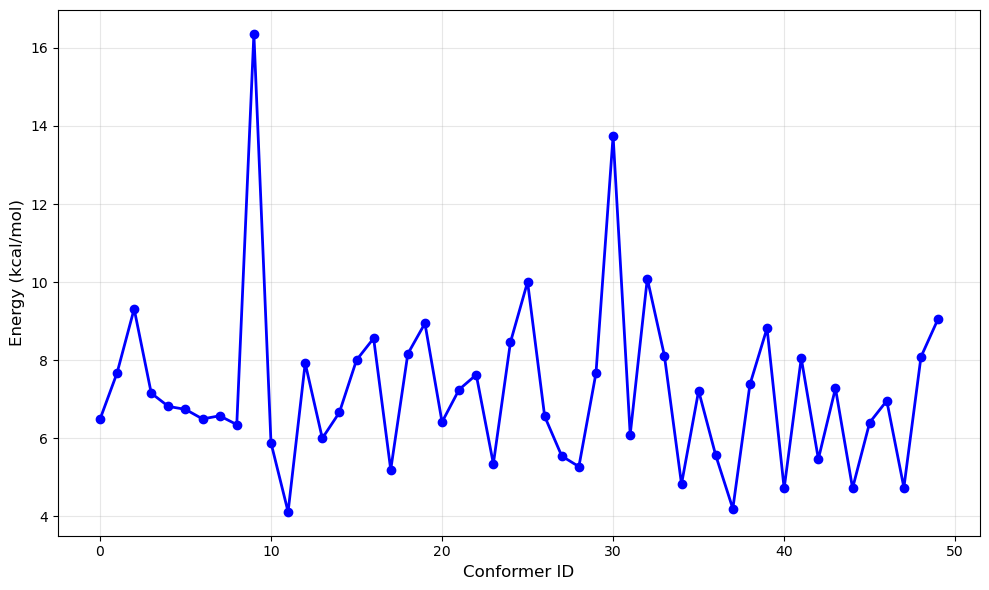

Energy Statistics:
Minimum Energy: 4.11 kcal/mol (Conformer 11)
Maximum Energy: 16.36 kcal/mol (Conformer 9)
Mean Energy: 7.22 kcal/mol
Standard Deviation: 2.17 kcal/mol
Energy Range: 12.25 kcal/mol


In [155]:
import numpy as np

import matplotlib.pyplot as plt

# Extract energies from the previous calculation
energy_values = [energy for conf_id, energy in energies]

# Create a plot showing energy distribution across conformers
plt.figure(figsize=(10, 6))

# Plot energy vs conformer ID
conformer_ids_list = [conf_id for conf_id, energy in energies]
plt.subplot()
plt.plot(conformer_ids_list, energy_values, 'bo-', markersize=6, linewidth=2)
plt.xlabel('Conformer ID', fontsize=12)
plt.ylabel('Energy (kcal/mol)', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
# plt.title('Energy vs Conformer ID')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/conformer_energies.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()

# Print statistics
print(f"Energy Statistics:")
print(f"Minimum Energy: {min(energy_values):.2f} kcal/mol (Conformer {min(energies, key=lambda x: x[1])[0]})")
print(f"Maximum Energy: {max(energy_values):.2f} kcal/mol (Conformer {max(energies, key=lambda x: x[1])[0]})")
print(f"Mean Energy: {np.mean(energy_values):.2f} kcal/mol")
print(f"Standard Deviation: {np.std(energy_values):.2f} kcal/mol")
print(f"Energy Range: {max(energy_values) - min(energy_values):.2f} kcal/mol")

### 9.2.2 Experimental-Torsion basic Knowledge Distance Geometry

In [156]:
#
# Code Example 9.2.2: Generating a conformer ensemble with ETKDG
#
from rdkit import Chem
from rdkit.Chem import AllChem

# Create a molecule object for butane, a simple flexible molecule
mol = Chem.MolFromSmiles('CCCC')
mol_with_hs = Chem.AddHs(mol)

# Generate a maximum of 10 conformers using the default ETKDG algorithm.
# The function returns a tuple of integer IDs for the conformers that were
# successfully generated and embedded.
conformer_ids = AllChem.EmbedMultipleConfs(mol_with_hs, numConfs=10)

print(f"Number of conformers successfully generated: {len(conformer_ids)}")

# The number of conformers might be less than 10 if the algorithm
# could not generate that many unique, low-energy structures.
# For butane, it will likely find only 2-3 distinct low-energy conformers.

Number of conformers successfully generated: 10


### 9.2.3 Universal Force Field

In [157]:
#
# Code Example 9.2.3: Refining a 3D conformer with the UFF
#
from rdkit import Chem
from rdkit.Chem import AllChem

# 1. Prepare the molecule with a 3D conformer
mol = Chem.MolFromSmiles('C1CCC1C') # Methylcyclopropane, has some inherent strain
mol_with_hs = Chem.AddHs(mol)
status = AllChem.EmbedMolecule(mol_with_hs)

if status == 0:
    # 2. Calculate the energy of the initial, unoptimized conformer
    # UFFGetMoleculeForceField creates a force field object for the molecule
    ff = AllChem.UFFGetMoleculeForceField(mol_with_hs)
    initial_energy = ff.CalcEnergy()
    print(f"Initial UFF Energy (raw conformer): {initial_energy:.2f} kcal/mol")

    # 3. Perform the UFF energy minimization. This modifies the coordinates in place.
    AllChem.UFFOptimizeMolecule(mol_with_hs)

    # 4. Recalculate the energy to confirm optimization
    # Note: It's good practice to re-create the force field object after optimization
    ff_opt = AllChem.UFFGetMoleculeForceField(mol_with_hs)
    optimized_energy = ff_opt.CalcEnergy()
    print(f"Final UFF Energy (optimized conformer): {optimized_energy:.2f} kcal/mol")
else:
    print("Conformer generation failed.")

Initial UFF Energy (raw conformer): 79.42 kcal/mol
Final UFF Energy (optimized conformer): 68.99 kcal/mol


Lowest energy: 27.26 kcal/mol at 185.1°
Highest energy: 2854298.35 kcal/mol at 0.0°
Saved 36 conformers to 'output/torsion_conformers.sdf'


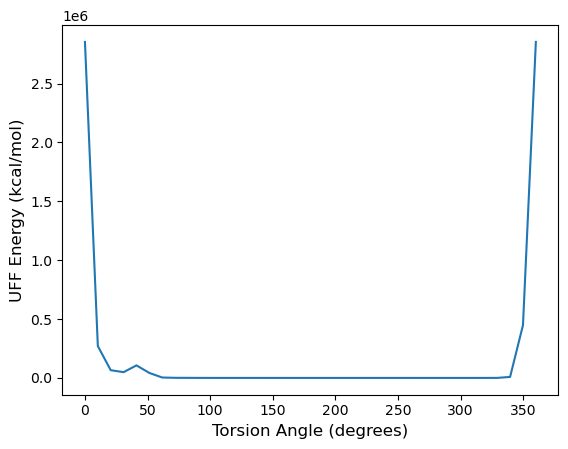

In [158]:
from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np
import matplotlib.pyplot as plt

mol = Chem.MolFromSmiles('CCCCCC')  # A simple flexible molecule (hexane)
mol_with_hs = Chem.AddHs(mol)
AllChem.EmbedMolecule(mol_with_hs)
angles = np.linspace(0, 360, 36)
energies = []
mol_confs = []
for angle in angles:
    # Set torsion angle (custom function needed)
    # Create a copy of the molecule for this angle
    mol_copy = Chem.Mol(mol_with_hs)
    conf = mol_copy.GetConformer()

    # Set the torsion angle for the C-C-C-C dihedral (atoms 0,1,2,3)
    # Convert angle from degrees to radians
    angle_rad = np.radians(angle)
    Chem.rdMolTransforms.SetDihedralDeg(conf, 0, 1, 2, 3, angle)
    ff = AllChem.UFFGetMoleculeForceField(mol_copy)
    energies.append(ff.CalcEnergy())
    mol_confs.append(mol_copy)
# Save the lowest and highest energy conformations
min_energy_idx = np.argmin(energies)
max_energy_idx = np.argmax(energies)

print(f"Lowest energy: {energies[min_energy_idx]:.2f} kcal/mol at {angles[min_energy_idx]:.1f}°")
print(f"Highest energy: {energies[max_energy_idx]:.2f} kcal/mol at {angles[max_energy_idx]:.1f}°")

# Save the conformations
writer = Chem.SDWriter(f'{OUTPUT_DIR}/torsion_conformers.sdf')
writer.write(mol_confs[min_energy_idx])
writer.write(mol_confs[max_energy_idx])
writer.close()

print(f"Saved {len(mol_confs)} conformers to '{OUTPUT_DIR}/torsion_conformers.sdf'")
plt.plot(angles, energies)
plt.xlabel("Torsion Angle (degrees)", fontsize=12)
plt.ylabel("UFF Energy (kcal/mol)", fontsize=12)
plt.savefig(f'{OUTPUT_DIR}/torsion_energy_plot.svg', format='svg', dpi=300, bbox_inches='tight')


### 9.2.4 Merck molecular force field

In [159]:
#
# Code Example 9.2.4: Optimizing a conformer with the MMFF94s force field
#
from rdkit import Chem
from rdkit.Chem import AllChem

# Create a molecule of acetamide, which contains a planar amide bond
mol = Chem.MolFromSmiles('CC(=O)N')
mol_with_hs = Chem.AddHs(mol)

# Generate an initial 3D conformer
status = AllChem.EmbedMolecule(mol_with_hs)

if status == 0:
    # To use MMFF, RDKit first needs to perceive MMFF atom types
    props = AllChem.MMFFGetMoleculeProperties(mol_with_hs, mmffVariant='MMFF94s')
    # Create the force field object using these properties
    ff = AllChem.MMFFGetMoleculeForceField(mol_with_hs, props)
    energy_before = ff.CalcEnergy()
    print(f"Initial MMFF94s Energy: {energy_before:.2f} kcal/mol")

    # Perform the optimization using the specified 'MMFF94s' variant
    AllChem.MMFFOptimizeMolecule(mol_with_hs, mmffVariant='MMFF94s')

    # Recalculate the energy of the now-optimized conformer
    ff_opt = AllChem.MMFFGetMoleculeForceField(mol_with_hs, props)
    energy_after = ff_opt.CalcEnergy()
    print(f"Final MMFF94s Energy:   {energy_after:.2f} kcal/mol")
else:
    print("Conformer generation failed.")
# Initial MMFF94s Energy: -11.23 kcal/mol
# Final MMFF94s Energy:   -28.46 kcal/mol

Initial MMFF94s Energy: -2.49 kcal/mol
Final MMFF94s Energy:   -28.46 kcal/mol


In [160]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw

mol = Chem.MolFromSmiles('CC(=O)N')
mol_with_hs = Chem.AddHs(mol)
AllChem.EmbedMolecule(mol_with_hs)
mol_with_hs_copy = Chem.Mol(mol_with_hs)
# Optimize the molecule using MMFF94
AllChem.MMFFOptimizeMolecule(mol_with_hs, mmffVariant='MMFF94')
writer = Chem.SDWriter(f'{OUTPUT_DIR}/acetamide_mmff94.sdf')
writer.write(mol_with_hs)
writer.close()
print(f"Optimized acetamide structure saved to '{OUTPUT_DIR}/acetamide_mmff94.sdf'")

AllChem.MMFFOptimizeMolecule(mol_with_hs_copy, mmffVariant='MMFF94s')
# Visualize with NGLView or export to PyMol
# Export the optimized structure to an SDF file for visualization
writer = Chem.SDWriter(f'{OUTPUT_DIR}/acetamide_mmff94s.sdf')
writer.write(mol_with_hs_copy)
writer.close()

print(f"Optimized acetamide structure saved to '{OUTPUT_DIR}/acetamide_mmff94s.sdf'")


Optimized acetamide structure saved to 'output/acetamide_mmff94.sdf'
Optimized acetamide structure saved to 'output/acetamide_mmff94s.sdf'


## 9.3 Molecular descriptor calculation

### 9.3.1 Constitutional descriptors

In [161]:
#
# Code Example 9.3.1: Calculating constitutional descriptors for caffeine
#
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

# Define the molecule (caffeine)
smiles = 'CN1C=NC2=C1C(=O)N(C(=O)N2C)C'
mol = Chem.MolFromSmiles(smiles)

if mol:
    # --- Calculate and print a selection of constitutional descriptors ---

    # Molecular Weight
    mol_wt = Descriptors.MolWt(mol)
    print(f"Molecular Weight: {mol_wt:.2f}")

    # Number of heavy (non-hydrogen) atoms
    heavy_atoms = Descriptors.HeavyAtomCount(mol)
    print(f"Heavy Atom Count: {heavy_atoms}")

    # Number of rotatable bonds (a measure of flexibility)
    rot_bonds = Descriptors.NumRotatableBonds(mol)
    print(f"Rotatable Bonds: {rot_bonds}")

    # Number of rings
    ring_count = Descriptors.RingCount(mol)
    print(f"Ring Count: {ring_count}")

    # --- Use the Lipinski module for H-bond donor/acceptor counts ---
    # (These are also considered constitutional descriptors)

    # Number of hydrogen bond acceptors (N, O atoms)
    h_acceptors = Lipinski.NumHAcceptors(mol)
    print(f"H-Bond Acceptors: {h_acceptors}")

    # Number of hydrogen bond donors (NH, OH groups)
    h_donors = Lipinski.NumHDonors(mol)
    print(f"H-Bond Donors: {h_donors}")

# The rdkit.Chem.Descriptors module contains over 200 descriptors,
# providing a rich source of features for model building.

Molecular Weight: 194.19
Heavy Atom Count: 14
Rotatable Bonds: 0
Ring Count: 2
H-Bond Acceptors: 6
H-Bond Donors: 0


In [162]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D

mol = Chem.MolFromSmiles('CN1C=NC2=C1C(=O)N(C(=O)N2C)C')  # Caffeine
drawer = rdMolDraw2D.MolDraw2DSVG(300, 300)
drawer.DrawMolecule(mol, highlightAtoms=[0, 1, 3])  # Example: Highlight N/O atoms
drawer.FinishDrawing()
svg = drawer.GetDrawingText()
with open(f'{OUTPUT_DIR}/caffeine_annotated.svg', 'w') as f:
    f.write(svg)

### 9.3.2 Topological descriptors

In [163]:
#
# Code Example 9.3.2: Calculating topological descriptors for ibuprofen
#
from rdkit import Chem
from rdkit.Chem import Descriptors

# Define the molecule (ibuprofen)
smiles = 'CC(C)CC1=CC=C(C=C1)C(C)C(=O)O'
mol = Chem.MolFromSmiles(smiles)

if mol:
    # --- Calculate and print a selection of topological descriptors ---

    # Topological Polar Surface Area (a key drug-likeness property)
    tpsa = Descriptors.TPSA(mol)
    print(f"TPSA: {tpsa:.2f}")

    # Balaban's J index (a shape and branching index)
    balaban_j = Descriptors.BalabanJ(mol)
    print(f"Balaban J Index: {balaban_j:.2f}")

    # --- Kappa Shape Indices ---
    kappa1 = Descriptors.Kappa1(mol)
    kappa2 = Descriptors.Kappa2(mol)
    kappa3 = Descriptors.Kappa3(mol)
    print(f"Kappa 1: {kappa1:.2f}")
    print(f"Kappa 2: {kappa2:.2f}")
    print(f"Kappa 3: {kappa3:.2f}")

TPSA: 37.30
Balaban J Index: 2.76
Kappa 1: 11.76
Kappa 2: 4.96
Kappa 3: 3.39


### 9.3.3 Connectivity descriptors

In [164]:
#
# Code Example 9.3.3: Using Chi indices to distinguish isomers
#
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors

# Define two C5H12 isomers
smiles_linear = 'CCCCC'    # n-pentane
smiles_branched = 'CC(C)CC' # Isopentane (2-methylbutane)

mol_linear = Chem.MolFromSmiles(smiles_linear)
mol_branched = Chem.MolFromSmiles(smiles_branched)

# --- A function to calculate and print Chi indices for a molecule ---
def print_chi_indices(name, mol):
    print(f"--- {name} ---")
    chi0n = rdMolDescriptors.CalcChi0n(mol)
    chi1n = rdMolDescriptors.CalcChi1n(mol)
    chi1v = rdMolDescriptors.CalcChi1v(mol)
    print(f"  Chi0n (atom-based): {chi0n:.3f}")
    print(f"  Chi1n (bond-based, simple): {chi1n:.3f}")
    print(f"  Chi1v (bond-based, valence): {chi1v:.3f}")
    print("-" * 15)

# --- Compare the two isomers ---
if mol_linear and mol_branched:
    print_chi_indices("n-Pentane (Linear)", mol_linear)
    print_chi_indices("Isopentane (Branched)", mol_branched)

--- n-Pentane (Linear) ---
  Chi0n (atom-based): 4.121
  Chi1n (bond-based, simple): 2.414
  Chi1v (bond-based, valence): 2.414
---------------
--- Isopentane (Branched) ---
  Chi0n (atom-based): 4.284
  Chi1n (bond-based, simple): 2.270
  Chi1v (bond-based, valence): 2.270
---------------


n-Pentane structure saved as 'output/npentane_chi.svg'


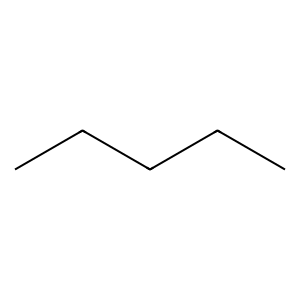

In [165]:
from rdkit import Chem
from rdkit.Chem import Draw, rdMolDescriptors
import io
from PIL import Image
import base64
from rdkit.Chem.Draw import rdMolDraw2D
mol = Chem.MolFromSmiles('CCCCC')  # n-Pentane
chi1n = rdMolDescriptors.CalcChi1n(mol)
img = Draw.MolToImage(mol)
# img.save('npentane_chi.png')
# Convert PIL image to SVG and save

# For SVG output, we can use RDKit's SVG drawing capabilities
# Create an SVG drawer
drawer = rdMolDraw2D.MolDraw2DSVG(300, 300)
drawer.DrawMolecule(mol)
drawer.FinishDrawing()

# Get the SVG string and save to file
svg_string = drawer.GetDrawingText()
with open(f'{OUTPUT_DIR}/npentane_chi.svg', 'w') as f:
    f.write(svg_string)

print(f"n-Pentane structure saved as '{OUTPUT_DIR}/npentane_chi.svg'")
img


In [166]:
def cal_chi_indices(bonds):
    chi1n = 0
    for delta_i, delta_j in bonds:
        chi1n += 1/ (delta_i * delta_j)**(1/2)
    return chi1n
# Example usage
bonds = [(1, 2), (2, 2), (2, 2), (2, 1)]
chi1n = cal_chi_indices(bonds)
# print(f"Chi1n: {chi1n:.3f}")  # Output:
chi1n

2.414213562373095

### 9.3.4 Geometric descriptors


In [167]:
#
# Code Example 9.3.4: Calculating 3D geometric descriptors
#
from rdkit import Chem
from rdkit.Chem import AllChem, rdMolDescriptors

# 1. Create the molecule object (toluene)
smiles = 'Cc1ccccc1'
mol = Chem.MolFromSmiles(smiles)

# 2. Add hydrogens, which are essential for realistic 3D geometry
mol_with_hs = Chem.AddHs(mol)

# 3. Generate a 3D conformer. This is the mandatory step for 3D descriptors.
# If this step fails or is omitted, the descriptor calculations will fail.
status = AllChem.EmbedMolecule(mol_with_hs)

# 4. (Recommended) Optimize the geometry with a force field
if status == 0:
    AllChem.MMFFOptimizeMolecule(mol_with_hs)

    # 5. Now, with a valid 3D conformer, calculate the geometric descriptors
    # Note: The conformer ID (-1) means use the default/first conformer
    npr1 = rdMolDescriptors.CalcNPR1(mol_with_hs, confId=-1)
    npr2 = rdMolDescriptors.CalcNPR2(mol_with_hs, confId=-1)
    spherocity = rdMolDescriptors.CalcSpherocityIndex(mol_with_hs, confId=-1)

    print(f"--- 3D Descriptors for Toluene ---")
    print(f"Spherocity Index: {spherocity:.3f}")
    print(f"NPR1 (PMI1/PMI3): {npr1:.3f}")
    print(f"NPR2 (PMI2/PMI3): {npr2:.3f}")
    print("----------------------------------")
else:
    print("Conformer generation failed; cannot calculate 3D descriptors.")

--- 3D Descriptors for Toluene ---
Spherocity Index: 0.060
NPR1 (PMI1/PMI3): 0.319
NPR2 (PMI2/PMI3): 0.692
----------------------------------


Text(0, 0.5, 'NPR2')

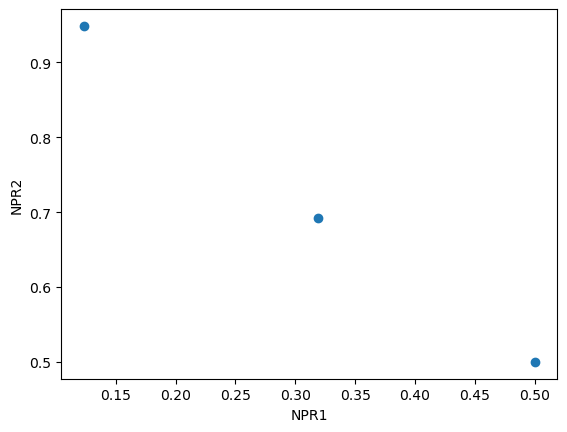

In [168]:
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem, rdMolDescriptors

molecules = ['Cc1ccccc1', 'c1ccccc1', 'CCCCCC']
npr_data = []
for smi in molecules:
    mol = Chem.MolFromSmiles(smi)
    mol_with_hs = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol_with_hs)
    AllChem.MMFFOptimizeMolecule(mol_with_hs)
    npr_data.append([rdMolDescriptors.CalcNPR1(mol_with_hs), rdMolDescriptors.CalcNPR2(mol_with_hs)])
plt.scatter([x[0] for x in npr_data], [x[1] for x in npr_data])
plt.xlabel('NPR1')
plt.ylabel('NPR2')


### 9.3.5 E-state descriptors


In [169]:
#
# Code Example 9.3.5: Calculating E-state descriptors
#
from rdkit import Chem
from rdkit.Chem import EState

# Use a molecule with varied atom types, like ethyl acetate
smiles = 'CCOC(=O)C'
mol = Chem.MolFromSmiles(smiles)

if mol:
    # --- 1. Calculate the raw E-state value for each atom ---
    # EStateIndices returns a tuple of E-state values, one for each atom.
    atom_estates = EState.EStateIndices(mol)
    print("--- Atom-Level E-State Indices ---")
    for i, estate in enumerate(atom_estates):
        atom_symbol = mol.GetAtomWithIdx(i).GetSymbol()
        print(f"  Atom {i} ({atom_symbol}): {estate:.3f}")
    print("-" * 34)

    # --- 2. Calculate molecule-level E-state VSA descriptors ---
    # These are 11 descriptors (EState_VSA1 to EState_VSA11) that sum the
    # surface area of atoms binned by their E-state values.
    vsa_descriptors = EState.EState_VSA.EState_VSA_(mol)
    print("\n--- Molecule-Level E-State VSA Descriptors ---")
    for i, vsa in enumerate(vsa_descriptors):
        print(f"  EState_VSA{i+1}: {vsa:.3f}")
    print("-" * 46)

--- Atom-Level E-State Indices ---
  Atom 0 (C): 1.779
  Atom 1 (C): 0.481
  Atom 2 (O): 4.403
  Atom 3 (C): -0.211
  Atom 4 (O): 9.822
  Atom 5 (C): 1.392
----------------------------------

--- Molecule-Level E-State VSA Descriptors ---
  EState_VSA1: 0.000
  EState_VSA2: 5.969
  EState_VSA3: 6.607
  EState_VSA4: 0.000
  EState_VSA5: 6.924
  EState_VSA6: 6.924
  EState_VSA7: 0.000
  EState_VSA8: 4.737
  EState_VSA9: 0.000
  EState_VSA10: 4.795
  EState_VSA11: 0.000
----------------------------------------------



### 9.3.6 Charge descriptors


In [170]:
#
# Code Example 9.3.6: Calculating and using Gasteiger partial charges
#
from rdkit import Chem
from rdkit.Chem import AllChem

# Use acetic acid, a molecule with several polar bonds
smiles = 'CC(=O)O'
mol = Chem.MolFromSmiles(smiles)
# Note: Unlike 3D descriptors, charges are calculated from topology,
# so a 3D conformer is not required.

if mol:
    # --- Part 1: Calculate and store the charges on each atom ---
    # This function modifies the molecule in place, adding a property to each atom.
    AllChem.ComputeGasteigerCharges(mol)

    print("--- Atom-Level Gasteiger Charges ---")
    charges = []
    for atom in mol.GetAtoms():
        # The charge is stored as a "double" (floating-point) property.
        charge = atom.GetDoubleProp('_GasteigerCharge')
        charges.append(charge)
        print(f"  Atom {atom.GetIdx()} ({atom.GetSymbol()}): {charge:+.3f}")
    print("-" * 36)


    # --- Part 2: Aggregate atom-level charges into molecule-level descriptors ---
    # Common descriptors are the max and min partial charges, which can indicate
    # the most likely sites for electrophilic or nucleophilic attack.
    max_pos_charge = max(charges)
    max_neg_charge = min(charges)

    print("\n--- Molecule-Level Charge Descriptors ---")
    print(f"  Max Positive Partial Charge: {max_pos_charge:+.3f}")
    print(f"  Max Negative Partial Charge: {max_neg_charge:+.3f}")
    print("-" * 39)

--- Atom-Level Gasteiger Charges ---
  Atom 0 (C): +0.034
  Atom 1 (C): +0.300
  Atom 2 (O): -0.253
  Atom 3 (O): -0.481
------------------------------------

--- Molecule-Level Charge Descriptors ---
  Max Positive Partial Charge: +0.300
  Max Negative Partial Charge: -0.481
---------------------------------------


In [171]:
from rdkit import Chem
from rdkit.Chem import AllChem, Draw

mol = Chem.MolFromSmiles('CC(=O)O')
AllChem.ComputeGasteigerCharges(mol)
charges = [atom.GetDoubleProp('_GasteigerCharge') for atom in mol.GetAtoms()]
img = Draw.MolToImage(mol, highlightAtoms=list(range(mol.GetNumAtoms())), highlightColors=[(c, 0, -c) for c in charges])
img.save(f'{OUTPUT_DIR}/acetic_acid_charges.png')


### 9.3.7 Kappa shape descriptors


In [172]:
#
# Code Example 9.3.8: Using Kappa indices to quantify molecular branching
#
from rdkit import Chem
from rdkit.Chem import Descriptors

# Define a set of C6H14 isomers with increasing branching
isomers = {
    "n-Hexane (Linear)": "CCCCCC",
    "2-Methylpentane (Branched)": "CC(C)CCC",
    "2,2-Dimethylbutane (Highly Branched)": "CC(C)(C)CC"
}

print(f"{'Isomer':<35} {'Kappa1':<10} {'Kappa2':<10} {'Kappa3':<10}")
print("-" * 65)

# Calculate and print the Kappa indices for each isomer
for name, smi in isomers.items():
    mol = Chem.MolFromSmiles(smi)
    if mol:
        kappa1 = Descriptors.Kappa1(mol)
        kappa2 = Descriptors.Kappa2(mol)
        kappa3 = Descriptors.Kappa3(mol)
        print(f"{name:<35} {kappa1:<10.3f} {kappa2:<10.3f} {kappa3:<10.3f}")

Isomer                              Kappa1     Kappa2     Kappa3    
-----------------------------------------------------------------
n-Hexane (Linear)                   6.000      5.000      4.000     
2-Methylpentane (Branched)          6.000      3.200      4.000     
2,2-Dimethylbutane (Highly Branched) 6.000      1.633      4.000     


Text(0, 0.5, 'Kappa Index Value')

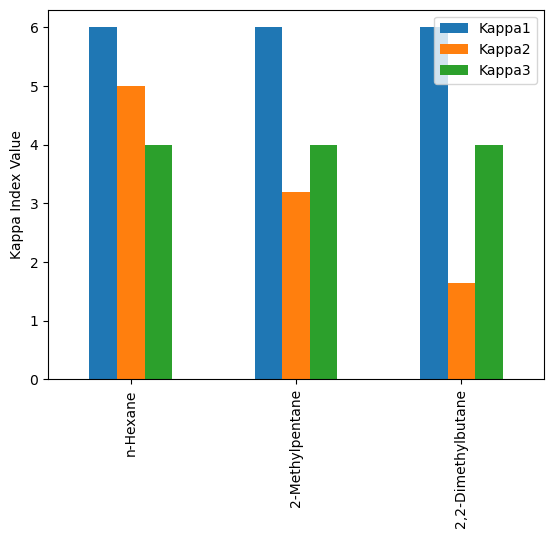

In [173]:
from rdkit import Chem
from rdkit.Chem import Descriptors
import matplotlib.pyplot as plt
import pandas as pd
isomers = {'n-Hexane': 'CCCCCC', '2-Methylpentane': 'CC(C)CCC', '2,2-Dimethylbutane': 'CC(C)(C)CC'}
kappa_data = {name: [Descriptors.Kappa1(Chem.MolFromSmiles(smi)),
                     Descriptors.Kappa2(Chem.MolFromSmiles(smi)),
                     Descriptors.Kappa3(Chem.MolFromSmiles(smi))]
              for name, smi in isomers.items()}
df = pd.DataFrame(kappa_data, index=['Kappa1', 'Kappa2', 'Kappa3']).T
df.plot(kind='bar')
plt.ylabel('Kappa Index Value')


### 9.3.8 Other descriptors


In [174]:
#
# Code Example 9.3.7: Listing available descriptors in RDKit
#
from rdkit.Chem import Descriptors

# Descriptors.descList is a list of (name, function) tuples
all_descriptor_names = [name for name, func in Descriptors.descList]

print(f"Number of descriptors in the main module: {len(all_descriptor_names)}")
print("A sample of available descriptors:")
print(all_descriptor_names[0:10]) # Print the first 10

Number of descriptors in the main module: 210
A sample of available descriptors:
['MaxAbsEStateIndex', 'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS', 'MolWt', 'HeavyAtomMolWt', 'ExactMolWt', 'NumValenceElectrons']



## 9.4 Molecular fingerprints



### 9.4.1 Morgan fingerprint


In [175]:
#
# Code Example 9.4.1: Generating a standard Morgan fingerprint
#
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, rdFingerprintGenerator
import numpy as np

# Create a molecule object from a SMILES string
smiles = 'CN1C=NC2=C1C(=O)N(C(=O)N2C)C'
mol = Chem.MolFromSmiles(smiles)

# --- Generate a standard Morgan fingerprint (bit vector) ---
radius = 2  # Corresponds to ECFP4
nBits = 2048

# Create a Morgan fingerprint generator
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(
    radius=radius,
    fpSize=nBits, 
    includeChirality=True
)

# Generate the fingerprint bit vector
fp_bitvect = morgan_gen.GetFingerprint(mol)

# The fingerprint can be converted to a NumPy array for use in machine learning
fp_array = np.zeros((1,), dtype=int)
DataStructs.ConvertToNumpyArray(fp_bitvect, fp_array)

print(f"Fingerprint bit vector length: {len(fp_bitvect)}")
print(f"Number of bits set: {fp_bitvect.GetNumOnBits()}")
# Example output:
# Fingerprint bit vector length: 2048
# Number of bits set: 25

# --- Generate a count-based Morgan fingerprint (unfolded) ---
# This version stores integer counts of each feature, rather than just presence (1) or absence (0)

# Create a count fingerprint generator
morgan_count_gen = rdFingerprintGenerator.GetMorganGenerator(
    radius=radius,
    includeChirality=True
)

fp_counts = morgan_count_gen.GetCountFingerprint(mol)

# Display some feature identifiers and their counts
print("\nExample count-based features (identifier: count):")
for feature_id, count in list(fp_counts.GetNonzeroElements().items())[:5]:
    print(f"{feature_id}: {count}")
# Example output:
# Example count-based features (identifier: count):
# 33: 1
# 314: 2
# 378: 1
# 400: 1
# 463: 1

Fingerprint bit vector length: 2048
Number of bits set: 25

Example count-based features (identifier: count):
33: 1
314: 2
378: 1
400: 1
463: 1



Visualizing bits: [33, 314, 378, 400, 463]


Bit 33 was generated by: ((4, 2),)
Bit 314 was generated by: ((7, 1), (10, 1))
Bit 378 was generated by: ((3, 0),)
Bit 400 was generated by: ((9, 2),)
Bit 463 was generated by: ((1, 2),)


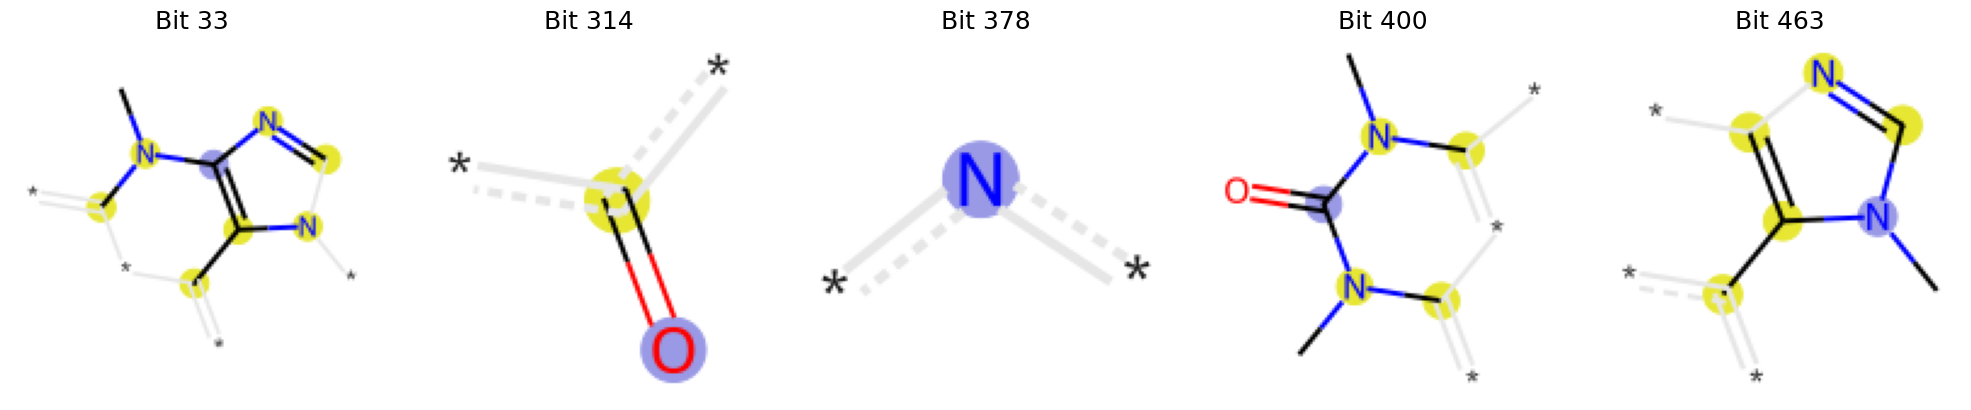

In [176]:
#
# Code Example 9.4.2: Visualizing a specific bit in the Morgan fingerprint
#
from rdkit.Chem import Draw
from rdkit.Chem.Draw import SimilarityMaps
from rdkit.Chem import rdFingerprintGenerator

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(
    radius=radius,
    fpSize=nBits,
    includeChirality=True
)

# Generate the fingerprint with additional output for bit information
additional_output = rdFingerprintGenerator.AdditionalOutput()
additional_output.AllocateBitInfoMap()

fp_with_info = morgan_gen.GetFingerprint(mol, additionalOutput=additional_output)
bitInfo = additional_output.GetBitInfoMap()

# Get the list of bits that are set to 1 in the fingerprint
on_bits = list(fp_with_info.GetOnBits())
if on_bits:
    import matplotlib.pyplot as plt
    
    # Choose the first 5 bits to visualize
    bits_to_visualize = on_bits[:5]
    
    print(f"\nVisualizing bits: {bits_to_visualize}")
    
    # Create a figure with subplots for each bit
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    
    for i, bit in enumerate(bits_to_visualize):
        print(f"Bit {bit} was generated by: {bitInfo[bit]}")
        
        # Generate the image for this bit
        bit_img = Draw.DrawMorganBit(mol, bit, bitInfo)
        
        # Display in subplot
        axes[i].imshow(bit_img)
        axes[i].set_title(f'Bit {bit}', fontsize=18)
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/morgan_bits_visualization.tiff', dpi=300, bbox_inches='tight')
    plt.show()


### 9.4.2 MACCS keys


In [177]:
#
# Code Example 9.4.3: Generating a MACCS keys fingerprint
#
from rdkit import Chem
from rdkit.Chem import MACCSkeys

# Create a molecule object from a SMILES string
aspirin_smiles = 'CC(=O)OC1=CC=CC=C1C(=O)O'
aspirin_mol = Chem.MolFromSmiles(aspirin_smiles)

# Generate the MACCS keys fingerprint
maccs_fp = MACCSkeys.GenMACCSKeys(aspirin_mol)

# The fingerprint is a 166-bit vector
print(f"MACCS fingerprint length: {maccs_fp.GetNumBits()}") # 167 because zero is empty. https://github.com/rdkit/rdkit/issues/1726
print(f"Number of bits set: {maccs_fp.GetNumOnBits()}")

MACCS fingerprint length: 167
Number of bits set: 21



### 9.4.3 PubChem fingerprint


In [178]:
#
# Code Example 9.4.4: Retrieving and decoding a PubChem fingerprint
#
import pubchempy as pcp
import base64

# Retrieve the compound for Aspirin by name
try:
    c = pcp.get_compounds('Aspirin', 'name')[0]
    
    # The fingerprint is stored in the 'fingerprint' attribute as a base64 string
    fp_b64 = c.fingerprint
    print(f"Base64-encoded fingerprint: {fp_b64[:30]}...")

    # Fix potential padding issues with base64 string
    # Add padding if necessary to make the length a multiple of 4
    missing_padding = len(fp_b64) % 4
    if missing_padding:
        fp_b64 += '=' * (4 - missing_padding)
    
    # To use the fingerprint, it must be decoded from base64
    fp_bytes = base64.b64decode(fp_b64)

    # Convert the bytes into a string of 1s and 0s
    # Each byte contains 8 bits, so we format it accordingly
    fp_bitstring = "".join(f"{byte:08b}" for byte in fp_bytes)
    
    print(f"Fingerprint length: {len(fp_bitstring)} bits")
    print(f"Decoded fingerprint (first 64 bits): {fp_bitstring[:64]}")
    
    # Additional information about the fingerprint
    print(f"Number of bits set to 1: {fp_bitstring.count('1')}")
    print(f"Number of bits set to 0: {fp_bitstring.count('0')}")

except IndexError:
    print("Compound 'Aspirin' not found in PubChem.")
except Exception as e:
    print(f"An error occurred: {e}")

Base64-encoded fingerprint: 00000371C070380000000000000000...
Fingerprint length: 1376 bits
Decoded fingerprint (first 64 bits): 1101001101001101001101001101001101111110111101010000101101001110
Number of bits set to 1: 732
Number of bits set to 0: 644



### 9.4.4 Daylight-like fingerprint in RDKit


In [179]:
#
# Code Example 9.4.5: Generating a Daylight-like fingerprint
#
from rdkit import Chem

# Create a molecule object for hexane
mol = Chem.MolFromSmiles('CCCCCC')

# Generate the Daylight-like fingerprint using default parameters
fp = Chem.RDKFingerprint(mol, minPath=1, maxPath=7, fpSize=2048)

print(f"Fingerprint length: {fp.GetNumBits()}")
print(f"Number of set bits: {fp.GetNumOnBits()}")

# Additional information
print(f"Density (fraction of bits set): {fp.GetNumOnBits() / fp.GetNumBits():.4f}")

# Get the indices of bits that are set to 1
on_bits = list(fp.GetOnBits())
print(f"First 10 indices of set bits: {on_bits[:10]}")

Fingerprint length: 2048
Number of set bits: 10
Density (fraction of bits set): 0.0049
First 10 indices of set bits: [148, 709, 803, 875, 1308, 1772, 1813, 1817, 1869, 1927]



### 9.4.5 Atom-pair fingerprint


In [180]:
#
# Code Example 9.4.6: Generating an AtomPair fingerprint
#
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator

# Use Celecoxib, a molecule with distinct, separated functional groups
smiles = 'CC1=CC=C(C=C1)C2=NN(C(=O)C2)C3=CC=C(C=C3)S(=O)(=O)N'
mol = Chem.MolFromSmiles(smiles)

# Create AtomPair fingerprint generator with explicit parameters
atom_pair_gen = rdFingerprintGenerator.GetAtomPairGenerator(
    minDistance=1,
    maxDistance=30,
    includeChirality=False,
    use2D=True,
    fpSize=2048
)

# Generate the folded bit vector
fp_bitvect = atom_pair_gen.GetFingerprint(mol)

print(f"Fingerprint length: {fp_bitvect.GetNumBits()}")
print(f"Number of set bits: {fp_bitvect.GetNumOnBits()}")
print(f"Fingerprint density: {fp_bitvect.GetNumOnBits() / fp_bitvect.GetNumBits():.4f}")

# Get the indices of bits that are set to 1
on_bits = list(fp_bitvect.GetOnBits())
print(f"First 10 indices of set bits: {on_bits[:10]}")

Fingerprint length: 2048
Number of set bits: 201
Fingerprint density: 0.0981
First 10 indices of set bits: [4, 8, 9, 16, 44, 100, 116, 117, 144, 145]



### 9.4.6 Topological-torsion fingerprint


In [181]:
#
# Code Example 9.4.7: Generating a Topological Torsion fingerprint
#
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator

# Use a flexible molecule like hexane to demonstrate
mol = Chem.MolFromSmiles('CCCCCC') 

# Create TopologicalTorsion fingerprint generator with explicit parameters
torsion_gen = rdFingerprintGenerator.GetTopologicalTorsionGenerator(
    torsionAtomCount=4,  # Length of the torsion path (default is 4)
    includeChirality=False,
    fpSize=2048
)

# Generate the folded bit vector, which is common for similarity searches
fp_bitvect = torsion_gen.GetFingerprint(mol)

print(f"Fingerprint length: {fp_bitvect.GetNumBits()}")
print(f"Number of set bits: {fp_bitvect.GetNumOnBits()}")
print(f"Fingerprint density: {fp_bitvect.GetNumOnBits() / fp_bitvect.GetNumBits():.4f}")


Fingerprint length: 2048
Number of set bits: 3
Fingerprint density: 0.0015



### 9.4.7 OpenBabel FP series fingerprints


In [182]:
#
# Code Example 9.4.8: Generating a FP2 fingerprint using Open Babel
#
from openbabel import pybel

# Read a molecule from a SMILES string
mol = pybel.readstring("smi", "CCO") 

# Generate the FP2 fingerprint (FP2 is the default fptype)
fp = mol.calcfp()

# The fingerprint object contains the set bits and other info
print(f"Number of set bits in FP2 fingerprint: {len(fp.bits)}")
print(f"Indices of set bits: {fp.bits}")

# Other fingerprints can be generated by specifying the type
maccs_fp = mol.calcfp(fptype='MACCS')
print(f"\nNumber of set bits in MACCS fingerprint: {len(maccs_fp.bits)}")

Number of set bits in FP2 fingerprint: 3
Indices of set bits: [516, 532, 671]

Number of set bits in MACCS fingerprint: 9



### 9.4.8 Mol2vec


In [213]:
# Use the raw file URL instead of the blob URL
model_url = "https://github.com/samoturk/mol2vec/raw/refs/heads/master/examples/models/model_300dim.pkl"
# Download the model file
import requests
response = requests.get(model_url)
if response.status_code != 200:
    raise Exception(f"Failed to download model: {response.status_code}")
with open(f'{OUTPUT_DIR}/model_300dim.pkl', 'wb') as f:
    f.write(response.content)

In [214]:
#
# Code Example 9.4.8: Generating a mol2vec vector for a molecule
#
from rdkit import Chem
from mol2vec.features import mol2alt_sentence
from gensim.models import word2vec

# 1. Load a pre-trained model (trained on a large chemical corpus)
model = word2vec.Word2Vec.load(f'{OUTPUT_DIR}/model_300dim.pkl') # https://github.com/samoturk/mol2vec/blob/master/examples/models/model_300dim.pkl

# 2. Represent a new molecule as a "sentence" of Morgan identifiers
mol = Chem.MolFromSmiles('CC(=O)Oc1ccccc1C(=O)O') # Aspirin
sentence = mol2alt_sentence(mol, radius=1)
print(f"Sentence representation: {sentence}")
# 3. Generate the molecule's vector by looking up and summing substructure vectors

molecule_vector = sum(model.wv[word] for word in sentence)

print(f"Mol2vec vector dimension: {len(molecule_vector)}")

Sentence representation: ['2246728737', '3545365497', '2246699815', '2664995851', '864942730', '1510328189', '864674487', '2077658817', '3217380708', '1135286194', '3218693969', '951226070', '3218693969', '98513984', '3218693969', '98513984', '3218693969', '951226070', '3217380708', '2309124039', '2246699815', '2784506312', '864942730', '1510328189', '864662311', '1533864325']
Mol2vec vector dimension: 300


[21:55:13] DEPRECATION WARNING: please use MorganGenerator



## 9.5 Molecular similarity



### 9.5.1 Fingerprint generation


In [184]:
#
# Code Example 9.5.1: Generating Morgan fingerprints
#
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator

# A sample list of molecules, including an invalid SMILES string
smiles_list = [
    "CCO",                      # Ethanol
    "c1ccccc1",                 # Benzene
    "CC(=O)Oc1ccccc1C(=O)O",     # Aspirin
    "invalid_molecule",         # An invalid entry
    "FC(F)(F)c1ccc(cc1)C(O)C(N)C(=O)O" # A more complex molecule
]

def generate_fingerprints(molecule_list: list, radius=2, nBits=2048) -> tuple:
    """Generates Morgan fingerprints for a list of SMILES strings using the new MorganGenerator."""
    valid_molecules = []
    fingerprints = []
    
    # Create a Morgan fingerprint generator with specified parameters
    morgan_gen = rdFingerprintGenerator.GetMorganGenerator(
        radius=radius,
        fpSize=nBits,
        includeChirality=False
    )
    
    for smi in molecule_list:
        mol = Chem.MolFromSmiles(smi)
        # Always check for valid molecule objects
        if mol is not None:
            valid_molecules.append(mol)
            fp = morgan_gen.GetFingerprint(mol)
            fingerprints.append(fp)
        else:
            print(f"Warning: Could not parse SMILES '{smi}'. Skipping.")
    
    return valid_molecules, fingerprints

mols, fps = generate_fingerprints(smiles_list)

print(f"\nSuccessfully generated {len(fps)} fingerprints.")


Successfully generated 4 fingerprints.


[21:45:29] SMILES Parse Error: syntax error while parsing: invalid_molecule
[21:45:29] SMILES Parse Error: Failed parsing SMILES 'invalid_molecule' for input: 'invalid_molecule'



### 9.5.2 Similarity metrics


In [185]:
#
# Code Example 9.5.2: Calculating Tanimoto similarity between fingerprints
#
from rdkit import DataStructs

# Calculate the similarity between the first and third valid fingerprints
# Note: Python's list index will be 0 and 2 for the first and third elements
similarity_score = DataStructs.TanimotoSimilarity(fps[0], fps[2])

print(f"Tanimoto similarity between the first and third molecules: {similarity_score:.4f}")

Tanimoto similarity between the first and third molecules: 0.1111



### 9.5.3 Procedure of molecular similarity searching


In [186]:
#
# Code Example 9.5.3: Performing a similarity search using Morgan fingerprints
#
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator, DataStructs

def perform_similarity_search(query_smi: str, target_smiles: list, 
                              radius=2, n_bits=2048, top_n=5):
    """
    Performs a similarity search for a query molecule against a list of targets.

    Args:
        query_smi: The SMILES string of the query molecule.
        target_smiles: A list of SMILES strings for the target database.
        radius: The radius for the Morgan fingerprint.
        n_bits: The bit length for the Morgan fingerprint.
        top_n: The number of top results to return.

    Returns:
        A list of tuples, where each tuple contains (SMILES, similarity_score),
        sorted in descending order of similarity.
    """
    # 1. Create Morgan fingerprint generator
    morgan_gen = rdFingerprintGenerator.GetMorganGenerator(
        radius=radius,
        fpSize=n_bits,
        includeChirality=False
    )
    
    # 2. Generate the fingerprint for the query molecule
    query_mol = Chem.MolFromSmiles(query_smi)
    if not query_mol:
        raise ValueError("Invalid query SMILES provided.")
    query_fp = morgan_gen.GetFingerprint(query_mol)

    results = []
    # 3. Generate fingerprints for the target database and compare to the query
    for smi in target_smiles:
        target_mol = Chem.MolFromSmiles(smi)
        if not target_mol:
            continue  # Skip invalid target molecules
        
        target_fp = morgan_gen.GetFingerprint(target_mol)
        
        # 4. Calculate Tanimoto similarity
        similarity = DataStructs.TanimotoSimilarity(query_fp, target_fp)
        results.append((smi, similarity))
        
    # 5. Rank the results
    results.sort(key=lambda x: x[1], reverse=True)
    
    return results[:top_n]

# --- Example Usage ---
# Define the query molecule (Aspirin) and a small target database
query_molecule = "CC(=O)OC1=CC=CC=C1C(=O)O"
target_database = [
    "CC(=O)Oc1ccccc1C(=O)O",      # Aspirin (identical)
    "O=C(O)c1ccccc1OC(C)=O",      # Aspirin (different SMILES)
    "c1ccccc1C(=O)O",              # Benzoic acid
    "Cc1ccccc1",                   # Toluene
    "CC(=O)Nc1ccc(O)cc1",          # Paracetamol
    "c1ccccc1",                    # Benzene
    "CC(=O)O",                     # Acetic acid
]

# Perform the search
top_hits = perform_similarity_search(query_molecule, target_database)

# Print the ranked results
print(f"Top {len(top_hits)} molecules most similar to Aspirin:")
for smi, score in top_hits:
    print(f"  SMILES: {smi:<30} Similarity: {score:.4f}")

Top 5 molecules most similar to Aspirin:
  SMILES: CC(=O)Oc1ccccc1C(=O)O          Similarity: 1.0000
  SMILES: O=C(O)c1ccccc1OC(C)=O          Similarity: 1.0000
  SMILES: c1ccccc1C(=O)O                 Similarity: 0.3571
  SMILES: Cc1ccccc1                      Similarity: 0.2500
  SMILES: CC(=O)O                        Similarity: 0.2400



### 9.5.4 Similarity scores


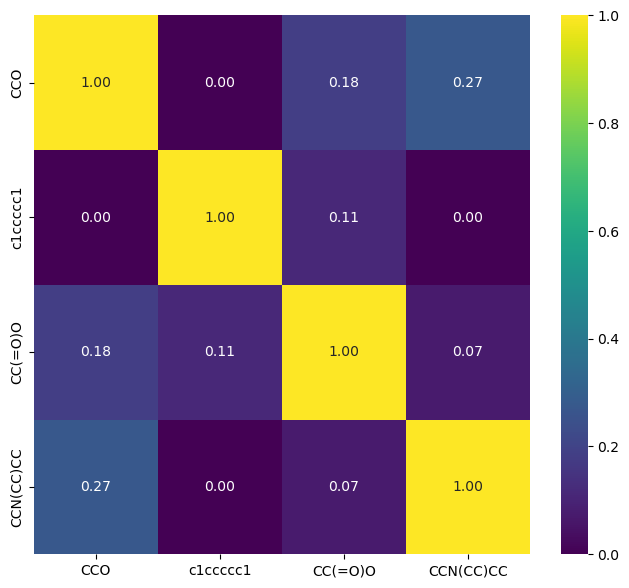

In [187]:
#
# Code Example 9.5.4: Visualizing molecular similarity using a heatmap
#
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from rdkit import DataStructs, Chem
from rdkit.Chem import rdFingerprintGenerator

# Create a Morgan fingerprint generator with specified parameters
smiles_list = ["CCO", "c1ccccc1", "CC(=O)O", "CCN(CC)CC"]
mols = [Chem.MolFromSmiles(s) for s in smiles_list]

# Create a Morgan fingerprint generator
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)
fps = [morgan_gen.GetFingerprint(mol) for mol in mols if mol]

# 1. Compute the all-vs-all similarity matrix
n_mols = len(fps)
similarity_matrix = np.zeros((n_mols, n_mols))
for i in range(n_mols):
    for j in range(n_mols):
        similarity = DataStructs.TanimotoSimilarity(fps[i], fps[j])
        similarity_matrix[i, j] = similarity

# 2. Visualize the matrix as a heatmap
plt.figure(figsize=(8, 7))
sns.heatmap(
    similarity_matrix, 
    annot=True,  # Annotate cells with the similarity value
    fmt=".2f",   # Format the annotation to two decimal places
    cmap="viridis",
    xticklabels=smiles_list, 
    yticklabels=smiles_list
)
# plt.title("Molecular Similarity Heatmap")

plt.savefig(f'{OUTPUT_DIR}/molecular_similarity_heatmap.tiff', dpi=300, bbox_inches='tight')
plt.show()


### 9.5.5 Visualization of similarity contributions


In [188]:
#
# Code Example 9.5.5: Generating a similarity map for a specific molecule
#
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import SimilarityMaps
import io
from PIL import Image
# Define the reference (Aspirin) and probe (Salicylic acid) molecules
ref_mol = Chem.MolFromSmiles("CC(=O)OC1=CC=CC=C1C(=O)O")
probe_mol = Chem.MolFromSmiles("OC1=CC=CC=C1C(=O)O")
# Function to display a PNG image from binary data
def show_png(data):
    bio = io.BytesIO(data)
    img = Image.open(bio)
    return img
# Generate the similarity map using a Morgan fingerprint
d = Draw.MolDraw2DCairo(400, 400)
_, maxWeight = SimilarityMaps.GetSimilarityMapForFingerprint(ref_mol, probe_mol, 
                                        lambda m, i: SimilarityMaps.GetMorganFingerprint(m, i, radius=2, fpType='bv'), 
                                        draw2d=d)
d.FinishDrawing()
# Display the similarity map as a SVG image
with open(f'{OUTPUT_DIR}/similarity_map.svg', 'wb') as f:
    f.write(d.GetDrawingText())
img=show_png(d.GetDrawingText())
img.save(f'{OUTPUT_DIR}/similarity_map.png', dpi=(300, 300))

[21:45:29] DEPRECATION WARNING: please use MorganGenerator
[21:45:29] DEPRECATION WARNING: please use MorganGenerator


In [189]:
from rdkit.Chem.Draw import rdMolDraw2D

# Save ref_mol (Aspirin) to SVG
ref_drawer = rdMolDraw2D.MolDraw2DSVG(400, 400)
ref_drawer.DrawMolecule(ref_mol)
ref_drawer.FinishDrawing()

with open(f'{OUTPUT_DIR}/ref_mol_aspirin.svg', 'w') as f:
    f.write(ref_drawer.GetDrawingText())

# Save probe_mol (Salicylic acid) to SVG
probe_drawer = rdMolDraw2D.MolDraw2DSVG(400, 400)
probe_drawer.DrawMolecule(probe_mol)
probe_drawer.FinishDrawing()

with open(f'{OUTPUT_DIR}/probe_mol_salicylic_acid.svg', 'w') as f:
    f.write(probe_drawer.GetDrawingText())

print(f"Saved ref_mol (Aspirin) structure to '{OUTPUT_DIR}/ref_mol_aspirin.svg'")
print(f"Saved probe_mol (Salicylic acid) structure to '{OUTPUT_DIR}/probe_mol_salicylic_acid.svg'")

Saved ref_mol (Aspirin) structure to 'output/ref_mol_aspirin.svg'
Saved probe_mol (Salicylic acid) structure to 'output/probe_mol_salicylic_acid.svg'


## 9.6 Chemical structure searching

### 9.6.1 SMILES arbitrary target specification

In [190]:
#
# Code Example 9.6.1: Substructure search for functional groups
#
from rdkit import Chem

# Define a molecule (aniline) using its SMILES string
mol = Chem.MolFromSmiles('Nc1ccccc1') # Aniline: an amino group on a benzene ring

# Define a SMARTS pattern for a primary amine nitrogen:
# a nitrogen atom ([N]) with exactly two attached hydrogens ([H2])
# and not part of an amide or similar electron-withdrawing system (implicitly handled by simple [N;H2])
amine_smarts_pattern = '[N;H2]'
amine_smarts = Chem.MolFromSmarts(amine_smarts_pattern)

# Perform the substructure search
# GetSubstructMatches returns a tuple of tuples, where each inner tuple contains
# the indices of the atoms in the molecule that match the SMARTS pattern.
matches = mol.GetSubstructMatches(amine_smarts)

if matches:
    print(f"Found {len(matches)} match(es) for the SMARTS pattern '{amine_smarts_pattern}':")
    for match_indices in matches:
        print(f"  Atom indices of the match: {match_indices}")
        # For a primary amine, this will typically be the index of the nitrogen atom.
        # We can also highlight which atoms are involved.
        # For instance, print the element of the matched atom(s)
        for atom_idx in match_indices:
            atom = mol.GetAtomWithIdx(atom_idx)
            print(f"    Atom {atom_idx}: {atom.GetSymbol()}")
else:
    print(f"No matches found for the SMARTS pattern '{amine_smarts_pattern}'.")

# Example for a more complex SMARTS: carboxylic acid C(=O)OH
# We can represent this as [CX3](=O)[OX2H1]
# C: Carbon, X3: with 3 explicit connections (excluding hydrogens unless specified)
# =O: double bonded to an oxygen
# [OX2H1]: an oxygen with 2 explicit connections and 1 hydrogen
carboxylic_acid_smarts_pattern = '[CX3](=O)[OX2H1]'
carboxylic_acid_smarts = Chem.MolFromSmarts(carboxylic_acid_smarts_pattern)
mol_ibuprofen = Chem.MolFromSmiles('CC(C)CC1=CC=C(C=C1)C(C)C(=O)O') # Ibuprofen

matches_cooh = mol_ibuprofen.GetSubstructMatches(carboxylic_acid_smarts)

if matches_cooh:
    print(f"\nFound {len(matches_cooh)} carboxylic acid group(s) in Ibuprofen:")
    for match_indices in matches_cooh:
        print(f"  Atom indices of the match: {match_indices}")
else:
    print("\nNo carboxylic acid group found in Ibuprofen.")


Found 1 match(es) for the SMARTS pattern '[N;H2]':
  Atom indices of the match: (0,)
    Atom 0: N

Found 1 carboxylic acid group(s) in Ibuprofen:
  Atom indices of the match: (12, 13, 14)


### 9.6.2 Full structure search

In [191]:
#
# Code Example 9.6.2: Performing a full structure search
#
from rdkit import Chem
from rdkit.Chem.MolStandardize import rdMolStandardize # For tautomer normalization

# Query molecule: L-lactic acid
query_smiles = "C[C@H](O)C(=O)O"
query_mol = Chem.MolFromSmiles(query_smiles)

# It's good practice to standardize the query molecule if tautomerism or
# other variations might be an issue. For simple exact match, canonical SMILES
# often handles most basic structural equivalence.
# Example of tautomer normalization for the query molecule:
tautomer_enumerator = rdMolStandardize.TautomerEnumerator()
normalized_query_mol = tautomer_enumerator.Canonicalize(query_mol)
query_canonical_smiles = Chem.MolToSmiles(normalized_query_mol, canonical=True)

print(f"Query Molecule SMILES: {query_smiles}")
print(f"Query Canonical SMILES (after tautomer normalization): {query_canonical_smiles}\n")

# A small example database of SMILES strings
database_smiles = [
    "C[C@H](O)C(=O)O",    # L-lactic acid (exact match to query)
    "C[C@@H](O)C(=O)O",   # D-lactic acid (enantiomer)
    "CC(O)C(=O)O",        # Lactic acid (no stereochemistry specified)
    "OCC(=O)O",          # Glycolic acid (different molecule)
    "OC(=O)[C@H](C)O"     # L-lactic acid (different SMILES representation)
]

print("Performing full structure search against the database:")
for i, db_smi in enumerate(database_smiles):
    db_mol = Chem.MolFromSmiles(db_smi)
    if db_mol is None:
        print(f"Entry {i+1} ('{db_smi}') is invalid. Skipping.")
        continue

    # Normalize and canonicalize the database molecule
    normalized_db_mol = tautomer_enumerator.Canonicalize(db_mol)
    db_canonical_smiles = Chem.MolToSmiles(normalized_db_mol, canonical=True)

    match_status = "No Match"
    if db_canonical_smiles == query_canonical_smiles:
        match_status = "Exact Match (via Canonical SMILES)"
    
    print(f"  Entry {i+1}: '{db_smi}' -> Canonical: '{db_canonical_smiles}' -> {match_status}")


Query Molecule SMILES: C[C@H](O)C(=O)O
Query Canonical SMILES (after tautomer normalization): CC(O)C(=O)O

Performing full structure search against the database:
  Entry 1: 'C[C@H](O)C(=O)O' -> Canonical: 'CC(O)C(=O)O' -> Exact Match (via Canonical SMILES)
  Entry 2: 'C[C@@H](O)C(=O)O' -> Canonical: 'CC(O)C(=O)O' -> Exact Match (via Canonical SMILES)
  Entry 3: 'CC(O)C(=O)O' -> Canonical: 'CC(O)C(=O)O' -> Exact Match (via Canonical SMILES)
  Entry 4: 'OCC(=O)O' -> Canonical: 'O=C(O)CO' -> No Match
  Entry 5: 'OC(=O)[C@H](C)O' -> Canonical: 'CC(O)C(=O)O' -> Exact Match (via Canonical SMILES)


In [192]:
#
# Code Example 9.6.3: Performing a full structure search using reciprocal substructure matching
#
# An alternative method for exact match using molecular graph comparison
# This often involves a reciprocal substructure match, ensuring all atoms and bonds
# correspond, including stereochemistry if present in both molecules.
# RDKit's Mol.HasSubstructMatch considers stereochemistry by default if specified.
# For a true exact match, we check if query is a substructure of db_mol AND
# db_mol is a substructure of query, and they have the same number of atoms.

print("\nPerforming full structure search using reciprocal substructure matching:")
for i, db_smi in enumerate(database_smiles):
    db_mol = Chem.MolFromSmiles(db_smi)
    if db_mol is None:
        continue # Already handled above

    # Standardize db_mol before comparison
    normalized_db_mol = tautomer_enumerator.Canonicalize(db_mol)

    match_status = "No Match"
    # Check if number of atoms are the same first (quick filter)
    if normalized_query_mol.GetNumAtoms() == normalized_db_mol.GetNumAtoms():
        # Check if query is a substructure of db_mol AND db_mol is a substructure of query
        # This implicitly checks for isomorphism including stereochemistry.
        if normalized_query_mol.HasSubstructMatch(normalized_db_mol) and \
           normalized_db_mol.HasSubstructMatch(normalized_query_mol):
            match_status = "Exact Match (Reciprocal Substructure Check)"
            
    print(f"  Entry {i+1}: '{db_smi}' -> {match_status}")



Performing full structure search using reciprocal substructure matching:
  Entry 1: 'C[C@H](O)C(=O)O' -> Exact Match (Reciprocal Substructure Check)
  Entry 2: 'C[C@@H](O)C(=O)O' -> Exact Match (Reciprocal Substructure Check)
  Entry 3: 'CC(O)C(=O)O' -> Exact Match (Reciprocal Substructure Check)
  Entry 4: 'OCC(=O)O' -> No Match
  Entry 5: 'OC(=O)[C@H](C)O' -> Exact Match (Reciprocal Substructure Check)


### 9.6.3 Substructure search

In [193]:
#
# Code Example 9.6.4: Searching for a substructure using SMARTS
#
from rdkit import Chem

# Define a target molecule, for example, ibuprofen
target_smiles = "CC(C)CC1=CC=C(C=C1)C(C)C(=O)O" # Ibuprofen
target_mol = Chem.MolFromSmiles(target_smiles)

if target_mol is None:
    print(f"Could not parse SMILES: {target_smiles}")
else:
    # Define a SMARTS pattern for a carboxylic acid group: [CX3](=O)[OX2H1]
    # [CX3]: Carbon with 3 connections (excluding implicit hydrogens)
    # (=O): Double bonded to an Oxygen
    # [OX2H1]: Oxygen with 2 connections and 1 explicit Hydrogen
    carboxylic_acid_smarts = "[CX3](=O)[OX2H1]"
    query_pattern = Chem.MolFromSmarts(carboxylic_acid_smarts)

    if query_pattern is None:
        print(f"Could not parse SMARTS: {carboxylic_acid_smarts}")
    else:
        # Check if the target molecule contains the substructure
        if target_mol.HasSubstructMatch(query_pattern):
            print(f"The molecule '{target_smiles}' contains the substructure '{carboxylic_acid_smarts}'.")
            
            # Get all matches (a molecule might contain the substructure multiple times)
            # GetSubstructMatches returns a tuple of tuples, each inner tuple containing atom indices of a match
            matches = target_mol.GetSubstructMatches(query_pattern)
            print(f"Found {len(matches)} instance(s) of the substructure.")
            for i, match_indices in enumerate(matches):
                print(f"  Match {i+1} involves atom indices: {match_indices}")
                # You can then use these indices to get atoms, bonds, etc.
                # For example, to list the elements of the matched atoms:
                matched_atoms_elements = [target_mol.GetAtomWithIdx(idx).GetSymbol() for idx in match_indices]
                print(f"    Elements of matched atoms: {matched_atoms_elements}")
        else:
            print(f"The molecule '{target_smiles}' does not contain the substructure '{carboxylic_acid_smarts}'.")

    # Example with a different SMARTS: an isopropyl group
    isopropyl_smarts = "C([CH3])[CH3]" # A carbon attached to two methyl groups
    query_isopropyl = Chem.MolFromSmarts(isopropyl_smarts)
    if query_isopropyl:
         if target_mol.HasSubstructMatch(query_isopropyl):
            matches_isopropyl = target_mol.GetSubstructMatches(query_isopropyl)
            print(f"\nThe molecule also contains an isopropyl group (matches: {len(matches_isopropyl)}). First match indices: {matches_isopropyl[0]}")
         else:
            print("\nThe molecule does not contain an isopropyl group.")


The molecule 'CC(C)CC1=CC=C(C=C1)C(C)C(=O)O' contains the substructure '[CX3](=O)[OX2H1]'.
Found 1 instance(s) of the substructure.
  Match 1 involves atom indices: (12, 13, 14)
    Elements of matched atoms: ['C', 'O', 'O']

The molecule also contains an isopropyl group (matches: 1). First match indices: (1, 0, 2)


In [194]:
from rdkit import Chem

# Assume 'molecule_list' is a list of RDKit Mol objects, 
# perhaps loaded from an SDF file or another source.
# Example: molecules_list = [Chem.MolFromSmiles("CCO"), Chem.MolFromSmiles("c1ccccc1O"), Chem.MolFromSmiles("CC(=O)O")]

# Define the SMARTS pattern, e.g., an alcohol group (-OH not part of carboxylic acid)
# [OX2H] matches an oxygen with 2 bonds and 1 hydrogen.
# To be more specific and exclude carboxylic acids, one might use a more complex SMARTS
# like [OX2H1;!$(OC(=O))] (oxygen with one H, not part of an ester/acid O-C=O)
alcohol_smarts_pattern = "[OX2H1;!$(OC(=O))]" 
alcohol_query = Chem.MolFromSmarts(alcohol_smarts_pattern)

# Example molecule list
molecules_list = [
    Chem.MolFromSmiles("CCO"),          # Ethanol (should match)
    Chem.MolFromSmiles("c1ccccc1O"),    # Phenol (should match)
    Chem.MolFromSmiles("CC(=O)O"),      # Acetic acid (should NOT match)
    Chem.MolFromSmiles("CC(=O)OCC"),    # Ethyl acetate (ester -OH, should NOT match if pattern is specific)
    Chem.MolFromSmiles("CCC")           # Propane (no alcohol, should NOT match)
]
# Filter out None values in case of parsing errors
molecules_list = [m for m in molecules_list if m is not None]


if alcohol_query:
    molecules_with_alcohol = []
    for mol in molecules_list:
        if mol.HasSubstructMatch(alcohol_query):
            molecules_with_alcohol.append(mol)
            print(f"Molecule '{Chem.MolToSmiles(mol)}' contains an alcohol group.")
    
    print(f"\nFound {len(molecules_with_alcohol)} molecule(s) containing the specified alcohol substructure.")
else:
    print(f"Could not parse the SMARTS pattern: {alcohol_smarts_pattern}")


Molecule 'CCO' contains an alcohol group.
Molecule 'Oc1ccccc1' contains an alcohol group.

Found 2 molecule(s) containing the specified alcohol substructure.


### 9.6.4 3D structure search

In [195]:
#
# Code Example 9.6.5: Performing a full structure search using 3D conformers
#
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdMolAlign # For alignments and RMSD

# --- Generating a 3D conformer for a molecule ---
# This molecule could serve as a query or be part of a database.
smiles_ethanol = "CCO"
mol_ethanol = Chem.MolFromSmiles(smiles_ethanol)
mol_ethanol_h = Chem.AddHs(mol_ethanol) # Add hydrogens for more realistic 3D structure

# Embed a 3D conformer (generate 3D coordinates)
# EmbedMolecule can sometimes fail, so it's good to check its return status
embed_success = AllChem.EmbedMolecule(mol_ethanol_h, AllChem.ETKDG()) # Using ETKDG algorithm
if embed_success == -1:
    print(f"Conformer generation failed for {smiles_ethanol}.")
else:
    print(f"Generated 3D conformer for {smiles_ethanol}.")
    mol_ethanol_3d = Chem.RemoveHs(mol_ethanol_h) # Remove Hs from the molecule at this point because they aren’t particularly informative for the rest of the analysis and they just make things more difficult
    # Now mol_ethanol_3d has 3D coordinates. Its conformer could be used as a query.

# --- Aligning two molecules and calculating RMSD ---
# Let's create another molecule, e.g., propanol, and compare its shape to ethanol.
smiles_propanol = "CCCO"
mol_propanol = Chem.MolFromSmiles(smiles_propanol)
mol_propanol_h = Chem.AddHs(mol_propanol)
embed_success_propanol = AllChem.EmbedMolecule(mol_propanol_h, AllChem.ETKDG())
mol_propanol_3d = Chem.RemoveHs(mol_propanol_h) 

if embed_success != -1 and embed_success_propanol != -1:
    # Align propanol to ethanol. AlignMol modifies the coordinates of the probe molecule (mol_propanol_h).
    # It returns the RMSD value. We need to specify which conformer ID to use (usually 0 if only one).
    try:
        rmsd_value = rdMolAlign.AlignMol(mol_ethanol_3d, mol_propanol_3d)
        print(f"RMSD between aligned ethanol and propanol: {rmsd_value:.3f} Å")
    except RuntimeError as e:
        print(f"Could not align molecules: {e}") # Alignment can fail if molecules are too different

# --- Working with multiple conformers and RMSD ---
# Generate multiple conformers for a flexible molecule, e.g., Butanol
smiles_butanol = "CCCCO"
mol_butanol = Chem.MolFromSmiles(smiles_butanol)
mol_butanol_h = Chem.AddHs(mol_butanol)

# EmbedMultipleConfs returns a list of conformer IDs
# numConfs specifies the target number of conformers
conformer_ids = AllChem.EmbedMultipleConfs(mol_butanol_h, numConfs=10, params=AllChem.ETKDG())
print(f"\nGenerated {len(conformer_ids)} conformers for butanol.")
mol_butanol_3d = Chem.RemoveHs(mol_butanol_h) # Remove Hs for further analysis

if len(conformer_ids) > 1:
    # Calculate RMSD between the first two conformers of butanol as an example
    # GetBestRMS does not modify coordinates, just calculates the RMSD of the best alignment
    rmsd_conformers = rdMolAlign.GetBestRMS(mol_butanol_3d, mol_butanol_3d, prbId=conformer_ids[1], refId=conformer_ids[0])
    print(f"RMSD between conformer {conformer_ids[0]} and {conformer_ids[1]} of butanol: {rmsd_conformers:.3f} Å")

    # A conceptual loop: imagine mol_ethanol_h is our 3D query.
    # We search for butanol conformers similar to ethanol (this is a simplified example).
    print("\nRMSD of butanol conformers against ethanol query:")
    if embed_success != -1: # Ensure ethanol conformer exists
        for conf_id in conformer_ids:
            rmsd_to_query = rdMolAlign.GetBestRMS(mol_ethanol_3d, mol_butanol_3d, prbId=0, refId=conf_id)
            # A low RMSD might indicate some shape similarity to the query
            print(f"  Butanol conformer {conf_id} RMSD to ethanol: {rmsd_to_query:.3f} Å")


Generated 3D conformer for CCO.
RMSD between aligned ethanol and propanol: 0.054 Å

Generated 10 conformers for butanol.
RMSD between conformer 0 and 1 of butanol: 0.891 Å

RMSD of butanol conformers against ethanol query:
  Butanol conformer 0 RMSD to ethanol: 0.025 Å
  Butanol conformer 1 RMSD to ethanol: 0.008 Å
  Butanol conformer 2 RMSD to ethanol: 0.039 Å
  Butanol conformer 3 RMSD to ethanol: 0.021 Å
  Butanol conformer 4 RMSD to ethanol: 0.007 Å
  Butanol conformer 5 RMSD to ethanol: 0.010 Å
  Butanol conformer 6 RMSD to ethanol: 0.011 Å
  Butanol conformer 7 RMSD to ethanol: 0.050 Å
  Butanol conformer 8 RMSD to ethanol: 0.060 Å
  Butanol conformer 9 RMSD to ethanol: 0.028 Å


In [ ]:

from rdkit import Chem
from rdkit.Chem import AllChem, ChemicalFeatures
from rdkit import RDConfig
import os
import numpy as np

# A simple 3D pharmacophore matching function
def match_pharmacophore(query_feats, target_mol, distance_tolerance=1.0):
    """Check if target molecule matches the pharmacophore features of the query molecule"""
    # Add hydrogens and generate a 3D conformer for the target
    target_mol = Chem.AddHs(target_mol)
    AllChem.EmbedMolecule(target_mol)
    AllChem.UFFOptimizeMolecule(target_mol)
    
    # Extract pharmacophore features from the target molecule
    target_feats = featFactory.GetFeaturesForMol(target_mol)
    
    # Simplified check: verify if the target contains all the query feature types
    query_types = sorted([f.GetFamily() for f in query_feats])
    target_types = sorted([f.GetFamily() for f in target_feats])
    if not all(elem in target_types for elem in query_types):
        return False

    # Key step: Check if distances between feature points match.
    query_positions = {f.GetFamily(): np.array(f.GetPos()) for f in query_feats}
    
    query_dist_map = {}
    query_keys = sorted(list(query_positions.keys()))
    for i in range(len(query_keys)):
        for j in range(i + 1, len(query_keys)):
            dist = np.linalg.norm(query_positions[query_keys[i]] - query_positions[query_keys[j]])
            query_dist_map[f"{query_keys[i]}-{query_keys[j]}"] = dist

    # Check if a matching set of distances can be found in the target molecule
    target_pos_map = {f.GetFamily(): np.array(f.GetPos()) for f in target_feats}
    
    for key, q_dist in query_dist_map.items():
        feat1, feat2 = key.split('-')
        if feat1 in target_pos_map and feat2 in target_pos_map:
            t_dist = np.linalg.norm(target_pos_map[feat1] - target_pos_map[feat2])
            if abs(q_dist - t_dist) > distance_tolerance:
                return False  # Distance does not match
        else:
            return False  # A required feature is missing
            
    return True

In [ ]:
#
# Code Example 9.6.5: Application of the 3D pharmacophore matching function
#

# 1. Initialize pharmacophore feature factory
fdefFile = os.path.join(RDConfig.RDDataDir, 'BaseFeatures.fdef')
featFactory = ChemicalFeatures.BuildFeatureFactory(fdefFile)

# 2. Create query molecule and extract its features
query_mol = Chem.MolFromSmiles('c1ccccc1O')  # Phenol
query_mol = Chem.AddHs(query_mol)
AllChem.EmbedMolecule(query_mol)
AllChem.UFFOptimizeMolecule(query_mol)
query_feats = featFactory.GetFeaturesForMol(query_mol)
print(f"Query molecule features: {[f.GetFamily() for f in query_feats]}")

# 3. Define molecule database to search
database_mols = [
    Chem.MolFromSmiles('c1ccccc1O'),      # Phenol (should match)
    Chem.MolFromSmiles('c1ccc(O)cc1'),    # Phenol (isomer, should match)
    Chem.MolFromSmiles('c1ccccc1'),       # Benzene (should not match)
    Chem.MolFromSmiles('CCO'),            # Ethanol (should not match)
    Chem.MolFromSmiles('c1ccccc1C(=O)O'),  # Benzoic acid (should match)
]

# 4. Search each molecule in the database
print("\n--- Search Results ---")
for i, mol in enumerate(database_mols):
    if mol is None: continue
    # Check if it matches the pharmacophore model
    is_match = match_pharmacophore(query_feats, mol, distance_tolerance=1.0)
    
    # Output results
    mol_name = Chem.MolToSmiles(mol)
    if is_match:
        print(f"Molecule {i+1} ({mol_name}): Matches pharmacophore model")
    else:
        print(f"Molecule {i+1} ({mol_name}): Does not match pharmacophore model")

Query molecule features: ['Donor', 'Acceptor', 'Aromatic', 'Hydrophobe', 'Hydrophobe', 'Hydrophobe', 'Hydrophobe', 'Hydrophobe', 'LumpedHydrophobe']

--- Search Results ---
Molecule 1 (Oc1ccccc1): Matches pharmacophore model
Molecule 2 (Oc1ccccc1): Does not match pharmacophore model
Molecule 3 (c1ccccc1): Does not match pharmacophore model
Molecule 4 (CCO): Does not match pharmacophore model
Molecule 5 (O=C(O)c1ccccc1): Matches pharmacophore model


## 9.7 Chemical transformations and reactions

### 9.7.1 Substructure-based transformations

In [196]:
#
# Code Example 9.7.1: Performing a reaction using RDKit
#
from rdkit import Chem
from rdkit.Chem import AllChem

# Define the reaction SMARTS for ester hydrolysis.
# Reactant: R-C(=O)O-R'  Product: R-C(=O)OH + R'-OH
# [C:1](=[O:2])-[O:3]-[C:4]>>[C:1](=[O:2])-[O:3].[C:4][O-] # Simplified: forms carboxylate and alcohol-like
# A more common representation for hydrolysis product:
# [C:1](=[O:2])-[O:3]-[C:4]>>[C:1](=[O:2])O.[C:4]O  (assuming H+ is added to O3 and OH to C4 after cleavage conceptually)
# RDKit's reaction SMARTS for hydrolysis might look like:
# [CX3:1](=[OX1:2])[OX2H0:3][CX4:4]>>[CX3:1](=[OX1:2])[OX2H1:3].[CX4:4][OX2H1]
# Let's use a simpler example for clarity: N-alkylation of a primary amine
# R-NH2 + R'-X  -> R-NH-R' (Here, we'll just show addition to an amine)
# Example: Adding a methyl group to a primary amine nitrogen.
# Reactant pattern: primary amine nitrogen. Product: secondary amine with a new methyl.
# [N;H2;$(N-[#6]):1]>>[N;H1;$(N-[#6]):1]C
# The $(N-[#6]) ensures the nitrogen is already bonded to a carbon (not ammonia)
reaction_smarts_methylation = '[N;H2;$(N-[#6]):1]>>[N;H1;$(N-[#6]):1]C'
rxn_methylation = AllChem.ReactionFromSmarts(reaction_smarts_methylation)

# Define a molecule with a primary amine: e.g., propylamine
propylamine_smiles = "CCCN"
mol_propylamine = Chem.MolFromSmiles(propylamine_smiles)

if mol_propylamine and rxn_methylation:
    # Apply the reaction. RunReactants returns a tuple of tuples of product molecules.
    # Each inner tuple represents one set of products from one reaction event.
    product_sets = rxn_methylation.RunReactants((mol_propylamine,)) # Reactants is a tuple

    if product_sets:
        print(f"Transforming: {Chem.MolToSmiles(mol_propylamine)}")
        for i, product_tuple in enumerate(product_sets):
            print(f"  Product set {i+1}:")
            for product_mol in product_tuple:
                print(f"    Product SMILES: {Chem.MolToSmiles(product_mol)}")
    else:
        print(f"No transformation occurred for {propylamine_smiles} with rule '{reaction_smarts_methylation}'. Substructure likely not matched as expected.")
else:
    if not mol_propylamine:
        print(f"Could not parse molecule: {propylamine_smiles}")
    if not rxn_methylation:
        print(f"Could not parse reaction SMARTS: {reaction_smarts_methylation}")

# Another example: Reduction of a ketone to a secondary alcohol
# [C:1](=[O:2])([#6:3])[#6:4]>>[C:1]([O:2])([#6:3])[#6:4] (simplistic: changes C=O to C-O, H added implicitly by valency)
# More explicit: [C:1](=[O:2])>>[C:1][OH1:2]
reaction_smarts_reduction = '[C:1](=[O:2])>>[C:1][OH1:2]' # Map O, add H to it
rxn_reduction = AllChem.ReactionFromSmarts(reaction_smarts_reduction)
acetone_smiles = "CC(=O)C"
mol_acetone = Chem.MolFromSmiles(acetone_smiles)

if mol_acetone and rxn_reduction:
    product_sets_reduction = rxn_reduction.RunReactants((mol_acetone,))
    if product_sets_reduction:
        print(f"\nTransforming: {Chem.MolToSmiles(mol_acetone)}")
        for product_mol in product_sets_reduction[0]: # Assuming one product set
             print(f"  Product SMILES: {Chem.MolToSmiles(product_mol)}") # Should be CC(O)C
    else:
        print(f"No transformation occurred for {acetone_smiles}")


Transforming: CCCN
  Product set 1:
    Product SMILES: CCCNC

Transforming: CC(C)=O
  Product SMILES: CC(C)O


In [17]:
from rdkit.Chem import Draw
from rdkit import Chem
from rdkit.Chem import AllChem

# Example for propylamine
mol = Chem.MolFromSmiles("CCCN")
Draw.MolToFile(mol, f"{OUTPUT_DIR}/propylamine.svg", size=(200, 200))

# Example for N-methylpropylamine (post-transformation)
rxn = AllChem.ReactionFromSmarts('[N;H2;$(N-[#6]):1]>>[N;H1;$(N-[#6]):1]C')
product_sets = rxn.RunReactants((mol,))
product = product_sets[0][0]
Draw.MolToFile(product, f"{OUTPUT_DIR}/n-methylpropylamine.svg", size=(200, 200))

In [18]:
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Chem import ChemUtils
mol = Chem.MolFromSmiles("CCCN")
patt = Chem.MolFromSmarts('[N;H2;$(N-[#6])]')  # Primary amine pattern
matches = mol.GetSubstructMatches(patt)
drawer = rdMolDraw2D.MolDraw2DCairo(200, 200)
drawer.DrawMolecule(mol, highlightAtoms=matches[0])
drawer.FinishDrawing()
drawer.WriteDrawingText(f"{OUTPUT_DIR}/highlighted_propylamine.png")

### 9.7.2 Murcko Decomposition

In [197]:
#
# Code Example 9.7.2: Generating a Murcko scaffold
#
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold

# Example molecule: Sildenafil (Viagra)
sildenafil_smiles = "CCCC1=NN(C)C2=C1NC(=NC2=O)C1=C(OCC)C=CC(=C1)S(=O)(=O)N1CCN(C)CC1"
mol_sildenafil = Chem.MolFromSmiles(sildenafil_smiles)

if mol_sildenafil:
    # Generate the Murcko scaffold
    # This keeps all ring systems and the linkers between them.
    scaffold = MurckoScaffold.GetScaffoldForMol(mol_sildenafil)
    scaffold_smiles = Chem.MolToSmiles(scaffold)
    print(f"SMILES of original molecule (Sildenafil): {sildenafil_smiles}")
    print(f"SMILES of Murcko scaffold: {scaffold_smiles}")

    # It's also possible to generate a "generic" Murcko scaffold,
    # where all scaffold atoms are converted to generic atoms (e.g., carbon)
    # and all bond types to single bonds, to focus purely on the topology.
    generic_scaffold = MurckoScaffold.MakeScaffoldGeneric(mol_sildenafil)
    generic_scaffold_smiles = Chem.MolToSmiles(generic_scaffold)
    print(f"SMILES of Generic Murcko scaffold: {generic_scaffold_smiles}")

else:
    print(f"Could not parse SMILES: {sildenafil_smiles}")

# Another example: Atorvastatin (Lipitor)
atorvastatin_smiles = "CC(C)C1=C(C(=C(N1CC[C@@H]([C@H](CC(=O)O)O)O)C2=CC=C(C=C2)F)C3=CC=CC=C3)C(=O)NC4=CC=CC=C4"
mol_atorvastatin = Chem.MolFromSmiles(atorvastatin_smiles)

if mol_atorvastatin:
    scaffold_atorvastatin = MurckoScaffold.GetScaffoldForMol(mol_atorvastatin)
    print(f"\nSMILES of original molecule (Atorvastatin): {atorvastatin_smiles}")
    print(f"SMILES of Murcko scaffold for Atorvastatin: {Chem.MolToSmiles(scaffold_atorvastatin)}")


SMILES of original molecule (Sildenafil): CCCC1=NN(C)C2=C1NC(=NC2=O)C1=C(OCC)C=CC(=C1)S(=O)(=O)N1CCN(C)CC1
SMILES of Murcko scaffold: O=c1nc(-c2cccc(S(=O)(=O)N3CCNCC3)c2)[nH]c2cn[nH]c12
SMILES of Generic Murcko scaffold: CCCC1CCC(C(C)(C)C2CCC(C)CC2)CC1C1CC(C)C2C(C)CC(CCC)C2C1

SMILES of original molecule (Atorvastatin): CC(C)C1=C(C(=C(N1CC[C@@H]([C@H](CC(=O)O)O)O)C2=CC=C(C=C2)F)C3=CC=CC=C3)C(=O)NC4=CC=CC=C4
SMILES of Murcko scaffold for Atorvastatin: O=C(Nc1ccccc1)c1c[nH]c(-c2ccccc2)c1-c1ccccc1


In [198]:
from rdkit.Chem import AllChem as Chem
from rdkit.Chem.Scaffolds.MurckoScaffold import MurckoScaffoldSmiles
from rdkit.Chem.Draw import MolsMatrixToGridImage
from rdkit.Chem import Descriptors
smls = [
    "Cc1cc(Oc2nccc(CCCC)c2)ccc1",
    "c1c2ccccc2ccc1",
    "Cc1cc(Oc2nccc(CCC)c2)ccc1",
    "CCc1cc(Oc2nccc(CCC)c2)ccc1",
    "Cc1ccccc1",
    "Oc1ccccc1",
    "Nc1ccccc1",
    "c1c2cc(CC)ccc2ccc1",
    "Cc1c2ccccc2ccc1",
]
molecule_scaffold = {sml: MurckoScaffoldSmiles(sml) for sml in smls}
molecule_scaffold

{'Cc1cc(Oc2nccc(CCCC)c2)ccc1': 'c1ccc(Oc2ccccn2)cc1',
 'c1c2ccccc2ccc1': 'c1ccc2ccccc2c1',
 'Cc1cc(Oc2nccc(CCC)c2)ccc1': 'c1ccc(Oc2ccccn2)cc1',
 'CCc1cc(Oc2nccc(CCC)c2)ccc1': 'c1ccc(Oc2ccccn2)cc1',
 'Cc1ccccc1': 'c1ccccc1',
 'Oc1ccccc1': 'c1ccccc1',
 'Nc1ccccc1': 'c1ccccc1',
 'c1c2cc(CC)ccc2ccc1': 'c1ccc2ccccc2c1',
 'Cc1c2ccccc2ccc1': 'c1ccc2ccccc2c1'}

In [199]:
from rdkit.Chem.Draw import rdMolDraw2D
import io

scaffold_molecules = dict()
for molecule, scaffold in molecule_scaffold.items():
    if scaffold not in scaffold_molecules.keys():
        scaffold_molecules[scaffold] = [molecule]
    else:
        scaffold_molecules[scaffold].append(molecule)

molsMatrix = []
for scaffold, molecules_list in scaffold_molecules.items():
    molsMatrix.append(
        [Chem.MolFromSmiles(scaffold)]
        + [Chem.MolFromSmiles(sml) for sml in molecules_list]
    )
molsMatrix.sort(key=lambda row: Descriptors.MolWt(row[0]))
highlightAtomListsMatrix = []
for row in molsMatrix:
    scaffold_mol = row[0]
    molecules = row[1:]

    # Sort the molecules in the row by molecular weight (excluding the scaffold)
    molecules = sorted(molecules, key=Descriptors.MolWt)
    row[:] = [scaffold_mol] + molecules

    # Highlight the scaffold in each molecule; don't highlight the scaffold (first column)
    matches = [()] + [
        molecule.GetSubstructMatch(scaffold_mol) for molecule in molecules
    ]
    highlightAtomListsMatrix.append(matches)

    # Align the molecules so they're in the same orientation as the scaffold
    Chem.Compute2DCoords(scaffold_mol)
    for molecule in molecules:
        Chem.GenerateDepictionMatching2DStructure(molecule, scaffold_mol)
legendsMatrix = []
for row_num, row in enumerate(molsMatrix, start=1):
    n_examples = len(row) - 1
    if n_examples == 1:
        descr = "1 molecule"
    else:
        descr = f"{n_examples} molecules"
    labelsRow = [f"Scaffold #{row_num}", descr]
    labelsRow += [""] * (n_examples - 1)
    legendsMatrix.append(labelsRow)
MolsMatrixToGridImage(
    molsMatrix=molsMatrix,
    legendsMatrix=legendsMatrix,
    highlightAtomListsMatrix=highlightAtomListsMatrix,
)
# Save the grid image

# Draw the grid using the existing molsMatrix
grid_img = MolsMatrixToGridImage(
    molsMatrix=molsMatrix,
    legendsMatrix=legendsMatrix,
    highlightAtomListsMatrix=highlightAtomListsMatrix,
    
)
with open(f"{OUTPUT_DIR}/molecule_scaffolds.png", "wb+") as f:
    f.write(grid_img.data)

In [26]:
from rdkit import Chem
from rdkit.Chem import Draw
sildenafil_smiles = "CCCC1=NN(C)C2=C1NC(=NC2=O)C1=C(OCC)C=CC(=C1)S(=O)(=O)N1CCN(C)CC1"
mol = Chem.MolFromSmiles(sildenafil_smiles)
Draw.MolToFile(mol, "sildenafil.svg")

In [ ]:
from rdkit.Chem import rdMolDescriptors
ring_info = mol.GetRingInfo()
rings = ring_info.AtomRings()  # Returns indices of atoms in each ring
# rings


((3, 4, 5, 7, 8),
 (9, 10, 11, 12, 7, 8),
 (15, 19, 20, 21, 22, 14),
 (27, 28, 29, 31, 32, 26))

In [27]:
from rdkit.Chem.Scaffolds import MurckoScaffold
scaffold = MurckoScaffold.GetScaffoldForMol(mol)
Draw.MolToFile(scaffold, "sildenafil_scaffold.svg")

### 9.7.3 Recap and BRICS

In [200]:
#
# Code Example 9.7.3: Fragmenting a molecule using RECAP and BRICS
#
from rdkit import Chem
from rdkit.Chem import Recap, BRICS

# Example molecule: Celecoxib
celecoxib_smiles = "CC1=CC=C(C=C1)C1=C(C(=NN1)C1=CC=C(C=C1)S(=O)(=O)N)C(F)(F)F"
mol_celecoxib = Chem.MolFromSmiles(celecoxib_smiles)

if mol_celecoxib:
    print(f"Original molecule (Celecoxib): {celecoxib_smiles}")

    # --- RECAP Fragmentation ---
    # Recap.RecapDecompose returns a hierarchical tree of fragments.
    # The leaves of this tree are the terminal fragments.
    recap_hierarchy = Recap.RecapDecompose(mol_celecoxib)
    recap_fragments_smiles = list(recap_hierarchy.GetLeaves().keys()) # Get SMILES of leaf fragments

    print("\nRECAP Fragments (SMILES of leaf nodes):")
    if recap_fragments_smiles:
        for i, smi in enumerate(recap_fragments_smiles):
            print(f"  Fragment {i+1}: {smi}")
    else:
        print("  No RECAP fragments generated (molecule might be a single RECAP fragment).")
    
    # --- BRICS Fragmentation ---
    # BRICS.BRICSDecompose returns a set of SMILES strings for the fragments.
    # These SMILES strings will contain dummy atoms.
    brics_fragments_smiles_set = BRICS.BRICSDecompose(mol_celecoxib)

    print("\nBRICS Fragments (SMILES with dummy atoms):")
    if brics_fragments_smiles_set:
        for i, smi in enumerate(list(brics_fragments_smiles_set)):
            print(f"  Fragment {i+1}: {smi}")
            # Further inspect dummy atoms in each BRICS fragment
            frag_mol = Chem.MolFromSmiles(smi)
            if frag_mol:
                dummy_info = []
                for atom in frag_mol.GetAtoms():
                    if atom.GetAtomicNum() == 0: # Dummy atoms have atomic number 0
                        # Get the label (e.g., "1", "2") from the isotope property or atom map number
                        label = atom.GetAtomMapNum() if atom.GetAtomMapNum() != 0 else atom.GetIsotope()
                        dummy_info.append(f"[*] with label {label if label != 0 else 'none'}")
                if dummy_info:
                    print(f"    Contains dummy atoms: {', '.join(dummy_info)}")
    else:
        print("  No BRICS fragments generated.")

else:
    print(f"Could not parse SMILES: {celecoxib_smiles}")


Original molecule (Celecoxib): CC1=CC=C(C=C1)C1=C(C(=NN1)C1=CC=C(C=C1)S(=O)(=O)N)C(F)(F)F

RECAP Fragments (SMILES of leaf nodes):
  Fragment 1: *c1ccc(C)cc1
  Fragment 2: *c1n[nH]c(*)c1C(F)(F)F
  Fragment 3: *c1ccc(S(N)(=O)=O)cc1

BRICS Fragments (SMILES with dummy atoms):
  Fragment 1: [8*]C(F)(F)F
    Contains dummy atoms: [*] with label 8
  Fragment 2: [16*]c1ccc(S(N)(=O)=O)cc1
    Contains dummy atoms: [*] with label 16
  Fragment 3: [16*]c1ccc(C)cc1
    Contains dummy atoms: [*] with label 16
  Fragment 4: [14*]c1n[nH]c([14*])c1[16*]
    Contains dummy atoms: [*] with label 14, [*] with label 14, [*] with label 16


[['Cc1ccc(-c2[nH]nc(-c3ccc(S\n(N)(=O)=O)cc3)c2C(F)(F)F)cc1', '', '', '', '', ''], ['*c1ccc(C)cc1', '*c1[nH]nc(-c2ccc(S(N)(=O)\n=O)cc2)c1C(F)(F)F', '', '*c1ccc(S(N)(=O)=O)cc1', '*c1n[nH]c(-c2ccc(C)cc2)c1\nC(F)(F)F', ''], ['', '*c1n[nH]c(*)c1C(F)(F)F', '*c1ccc(S(N)(=O)=O)cc1', '', '*c1ccc(C)cc1', '*c1n[nH]c(*)c1C(F)(F)F']]


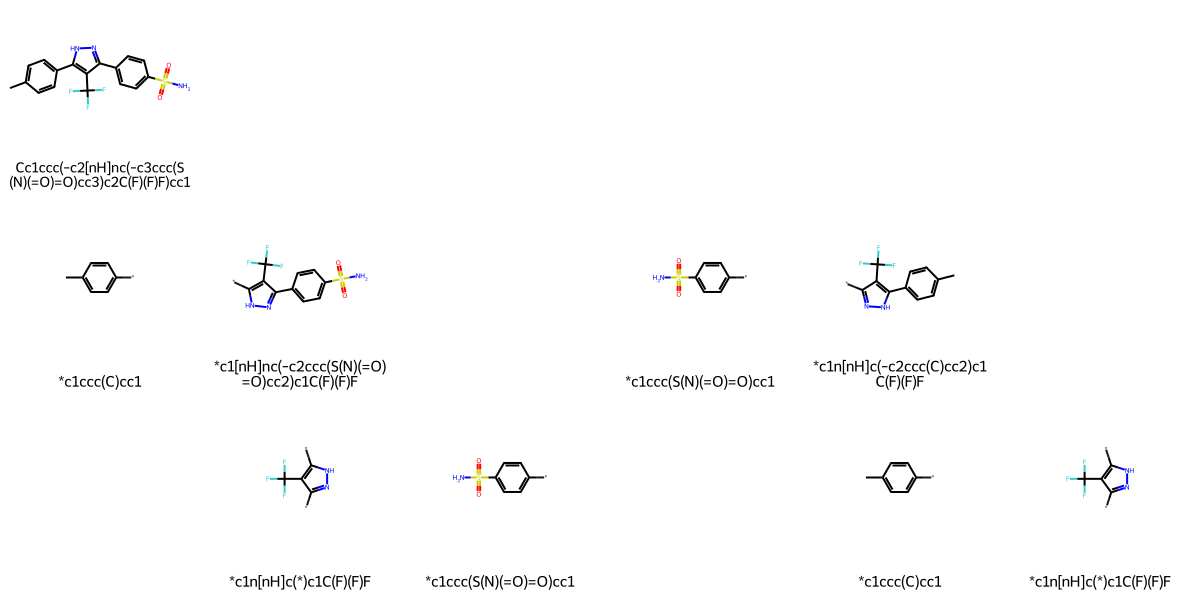

In [201]:
from rdkit import Chem
from rdkit.Chem import Draw, Recap
def molecule_recap_tree(smiles:str, name:str="", verbose=False, **kwargs):
    """
    Draw a molecular fragmentation tree using the Recap algorithm given in
    https://www.semanticscholar.org/paper/RECAP-%E2%80%94-Retrosynthetic-Combinatorial-Analysis-A-New-Lewell-Judd/fbfb10d1f63aa803f6d47df6587aa0e41109f5ee

    :returns: RDKit grid image, and (if verbose=True) RDKit molecule of parent molecule, Recap hierarchy, nonbinary tree hierarchy, and fragment grid
    :rtype: RDKit grid image, and (if verbose=True) rdkit.Chem.rdchem.Mol, rdkit.Chem.Recap.RecapHierarchyNode, NonBinTree, list[list[str]]
    :param smiles: The SMILES string of the molecule to be fragmented
    :param name: The name of the parent molecule; if not supplied, it will be labled with its SMILES string
    :param verbose: Whether to return verbose output; default is False so calling this function will present a grid image automatically
    """
    molecule = Chem.MolFromSmiles(smiles)
    RecapHierarchy = Recap.RecapDecompose(molecule)
    root = NonBinTree(RecapHierarchy.smiles)
    molecule_nonbinary_tree = get_children(RecapHierarchy, root)
    fragment_grid = molecule_nonbinary_tree.get_grid()
    mols_per_row = len(fragment_grid[0])
    recap_plot = [item for sublist in fragment_grid for item in sublist]
    recap_labels = [item for sublist in fragment_grid for item in sublist]
    if name:
        recap_labels[0] = name
    # Adjust labels to wrap if they exceed 15 characters
    # Use MolsMatrixToGridImage if available in the installed version of RDKit
    molsMatrix = [[Chem.MolFromSmiles(smile) for smile in sublist] for sublist in fragment_grid]
    k = 25
    for smis in fragment_grid:
        for i, smi in enumerate(smis):
            if len(smi) > k:
                smis[i] = smi[:k] + "\n" + smi[k:]  # Wrap at k characters
    print(fragment_grid)
    try:
        drawing = Draw.MolsMatrixToGridImage(molsMatrix=molsMatrix, legendsMatrix=fragment_grid, **kwargs)
    except AttributeError:
        drawing = Draw.MolsToGridImage([Chem.MolFromSmiles(smile) for smile in recap_plot], legends=recap_labels, molsPerRow=mols_per_row, **kwargs)
        
    if verbose:
          return drawing, molecule, RecapHierarchy, molecule_nonbinary_tree, fragment_grid
    else:
          return drawing

def concat_grids_horizontally(grid1:list[list[str]], grid2:list[list[str]]) -> list[list[str]]:
    """Concatenate two nested lists horizontally, for example
    inputs [['a'],['b'],['c']] and [['d'], ['e'], ['f']] 
    produce [['a', 'd'], ['b', 'e'], ['c', 'f']]

    :returns: The combined grid, a two-deep nested list of strings
    :param grid1: The first grid, a two-deep nested list of strings
    :param grid2: The second grid, a two-deep nested list of strings
    """
    if grid1 == [[]]:
        combined = grid2
    elif grid2 == [[]]:
        combined = grid1
    else:
        combined = []
        for row_counter in range(len(grid1)):
            combined += [grid1[row_counter] + grid2[row_counter]]
    return combined

class NonBinTree:
    """
    Nonbinary tree class
    Note that this class is not designed to sort nodes as they are added to the tree;
    the assumption is that they should be ordered in the order added
    Adapted from https://stackoverflow.com/questions/60579330/non-binary-tree-data-structure-in-python#60579464
    """

    def __init__(self, val:str):
        """Create a NonBinTree instance"""
        self.val = val
        self.nodes = []

    def add_node(self, val:str):
        """Add a node to the tree and return the new node"""
        self.nodes.append(NonBinTree(val))
        return self.nodes[-1]

    def __repr__(self) -> str:
        """Print out the tree as a nested list"""
        return f"NonBinTree({self.val}): {self.nodes}"

    def get_ncols(self) -> int:
        """Get the number of columns in the tree"""
        self.ncols = 0
        if len(self.nodes) > 0:
            # If there are nodes under this one, call get_ncols on them recursively
            for node in self.nodes:
                self.ncols += node.get_ncols()
        else:
            # If there are no nodes under this one, add 1 for this node
            self.ncols += 1
        return self.ncols

    def get_max_depth(self) -> int:
        """Get the maximum depth of the tree"""
        max_depth = 0
        if len(self.nodes) > 0:
            for node in self.nodes:
                this_depth = node.get_max_depth()
                max_depth = max(this_depth + 1, max_depth)
        else:
            max_depth = max(1, max_depth)
        self.max_depth = max_depth
        return self.max_depth

    def get_grid(self) -> list[list[str]]:
        """
        Get a two-dimensional grid where
        each row is a level in the fragment hierarchy, and
        the columns serve to arrange the fragments horizontally
        """
        # Call methods to calculate self.ncols and self.max_depth
        self.get_ncols()
        self.get_max_depth()

        # Create top row: Node value, then the rest of columns are blank (empty strings)
        grid = [[self.val] + [""] * (self.ncols - 1)]

        n_nodes = len(self.nodes)

        if n_nodes > 0:
            nodes_grid = [[]]

            # Iterate through the chile nodes
            for node_counter, node in enumerate(self.nodes):
                # Recursively call this function to get the grid for children
                node_grid = node.get_grid()

                # Add spacer rows if needed
                node_grid_rows = len(node_grid)
                rows_padding = self.max_depth - node_grid_rows - 1
                for padding in range(rows_padding):
                    node_grid += [[""] * len(node_grid[0])]

                nodes_grid = concat_grids_horizontally(nodes_grid, node_grid)

            grid += nodes_grid

        return grid
def get_children(base_node:Chem.Recap.RecapHierarchyNode, root:NonBinTree = None) -> NonBinTree:
    """
    Convert an RDKit RecapHierarchyNode into a NonBinTree by
    traversing the RecapHierarchyNode, getting all its children recursively, and adding them to a NonBinTree

    :returns: NoBinTree containing the Recap hierarchy
    :param base_node: The RDKit RecapHierarchyNode
    :param root: The NoBinTree containing only the root node
    """
    for smiles, node in base_node.children.items():
        added_tree_node = root.add_node(smiles)
        children = node.children.keys()
        # Sort the children nodes to get consistent ordering
        children = sorted(children)
        if len(children) > 0:
            get_children(node, added_tree_node)
    return root
opts = Draw.MolDrawOptions()
opts.legendFraction = 0.25
opts.legendFontSize = 15
default_kwargs = {
    'drawOptions': opts,    # 图例字体大小
    'subImgSize': (200, 200)  # 子图大小
}
molecule_recap_tree(celecoxib_smiles, "Parent molecule", **default_kwargs)

### 9.7.4 Chemical reactions based on reaction SMILES

In [202]:
#
# Code Example 9.7.4: Performing a reaction using SMIRKS
#
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.Draw import rdMolDraw2D
from matplotlib.patches import FancyBboxPatch

# Define the SMIRKS for amide bond formation.
# This rule states that a carboxylic acid reacts with an amine to form an amide and water.
# Reactant 1 (Carboxylic Acid): [C:1](=[O:2])[OH1:3] - Carbonyl carbon :1, carbonyl oxygen :2, hydroxyl oxygen :3
# Reactant 2 (Amine): [N!$(N=O):4][H:5] - Nitrogen :4 (not part of nitro/nitroso), and one of its hydrogens :5
# Product 1 (Amide): [C:1](=[O:2])[N:4] - New bond between C:1 and N:4
# Product 2 (Water): [O:3][H:5] - Formed from the -OH of the acid and -H of the amine
# Define SMIRKS for amide formation
amide_formation_smirks = "[C:1](=[O:2])[OH1:3].[N!$(N=O):4][H:5]>>[C:1](=[O:2])[N:4].[O:3][H:5]"

# Create reaction object
rxn = AllChem.ReactionFromSmarts(amide_formation_smirks)

# Define reactants
acetic_acid_smiles = "CC(=O)O"
ethylamine_smiles = "CCN"
mol_acid = Chem.MolFromSmiles(acetic_acid_smiles)
mol_amine = Chem.MolFromSmiles(ethylamine_smiles)

if mol_acid and mol_amine and rxn:
    # Sanitize molecules
    Chem.SanitizeMol(mol_acid)
    Chem.SanitizeMol(mol_amine)
    
    # Optional: Add explicit hydrogens
    mol_acid = Chem.AddHs(mol_acid)
    mol_amine = Chem.AddHs(mol_amine)
    
    # Debug: Print molecule SMILES
    print(f"Acid: {Chem.MolToSmiles(mol_acid, True)}")
    print(f"Amine: {Chem.MolToSmiles(mol_amine, True)}")
    print(f"Reaction valid: {rxn.Validate()[0] == 0}")

    # Run reaction
    product_sets = rxn.RunReactants((mol_acid, mol_amine))

    if product_sets:
        print(f"Reaction: {Chem.MolToSmiles(mol_acid)} + {Chem.MolToSmiles(mol_amine)} ->")
        for i, products_tuple in enumerate(product_sets):
            product_smiles_list = [Chem.MolToSmiles(prod_mol) for prod_mol in products_tuple]
            print(f"  Product Set {i+1}: {' . '.join(product_smiles_list)}")
    else:
        print(f"Reaction failed. Check SMIRKS and reactant compatibility.")
else:
    print("Error: Invalid molecules or reaction object. Check SMILES and SMIRKS.")
# Save molecule images for reactants and products
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Create SVG drawings for reactants and products
def draw_molecule_svg(mol, width=300, height=300):
    """Draw molecule as SVG string"""
    drawer = rdMolDraw2D.MolDraw2DSVG(width, height)
    drawer.DrawMolecule(mol)
    drawer.FinishDrawing()
    return drawer.GetDrawingText()

# Save individual molecule SVGs
if mol_acid and mol_amine and product_sets:
    # Draw reactants
    acid_svg = draw_molecule_svg(mol_acid)
    amine_svg = draw_molecule_svg(mol_amine)
    
    # Save reactant SVGs
    with open(f"{OUTPUT_DIR}/acetic_acid.svg", "w") as f:
        f.write(acid_svg)

    with open(f"{OUTPUT_DIR}/ethylamine.svg", "w") as f:
        f.write(amine_svg)
    
    # Draw and save products
    for i, products_tuple in enumerate(product_sets):
        for j, product_mol in enumerate(products_tuple):
            product_svg = draw_molecule_svg(product_mol)
            filename = f"product_set{i+1}_mol{j+1}.svg"
            with open(f"{OUTPUT_DIR}/{filename}", "w") as f:
                f.write(product_svg)
            print(f"Saved: {filename}")
    
    print("All molecule SVG files saved successfully!")

Acid: [H]OC(=O)C([H])([H])[H]
Amine: [H]N([H])C([H])([H])C([H])([H])[H]
Reaction valid: True
Reaction: [H]OC(=O)C([H])([H])[H] + [H]N([H])C([H])([H])C([H])([H])[H] ->
  Product Set 1: [H]N(C(=O)C([H])([H])[H])C([H])([H])C([H])([H])[H] . [H]O[H]
  Product Set 2: [H]N(C(=O)C([H])([H])[H])C([H])([H])C([H])([H])[H] . [H]O[H]
Saved: product_set1_mol1.svg
Saved: product_set1_mol2.svg
Saved: product_set2_mol1.svg
Saved: product_set2_mol2.svg
All molecule SVG files saved successfully!


In [203]:
# Acid: [H]OC(=O)C([H])([H])[H]
# Amine: [H]N([H])C([H])([H])C([H])([H])[H]
# Reaction valid: True
# Reaction: [H]OC(=O)C([H])([H])[H] + [H]N([H])C([H])([H])C([H])([H])[H] ->
#   Product Set 1: [H]N(C(=O)C([H])([H])[H])C([H])([H])C([H])([H])[H] . [H]O[H]
#   Product Set 2: [H]N(C(=O)C([H])([H])[H])C([H])([H])C([H])([H])[H] . [H]O[H]

### 9.7.5 Chemical reactions based MDL rxn files

In [206]:
rxn_content = """$RXN

      OpenBabel

  2  2
$MOL

 OpenBabel07022500482D

  4  3  0  0  0  0  0  0  0  0999 V2000
    0.0000    0.0000    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.0000    0.0000    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.0000    0.0000    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
    0.0000    0.0000    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
  1  2  1  0  0  0  0
  2  3  2  0  0  0  0
  2  4  1  0  0  0  0
M  END
$MOL

 OpenBabel07022500482D

  3  2  0  0  0  0  0  0  0  0999 V2000
    0.0000    0.0000    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.0000    0.0000    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.0000    0.0000    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
  1  2  1  0  0  0  0
  2  3  1  0  0  0  0
M  END
$MOL

 OpenBabel07022500482D

  6  5  0  0  0  0  0  0  0  0999 V2000
    0.0000    0.0000    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.0000    0.0000    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.0000    0.0000    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
    0.0000    0.0000    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.0000    0.0000    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
    0.0000    0.0000    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
  1  2  1  0  0  0  0
  2  3  1  0  0  0  0
  3  4  1  0  0  0  0
  4  5  2  0  0  0  0
  4  6  1  0  0  0  0
M  END
$MOL

 OpenBabel07022500482D

  1  0  0  0  0  0  0  0  0  0999 V2000
    0.0000    0.0000    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
M  END
"""
with open(f"{OUTPUT_DIR}/methyl_acetate_formation.rxn", "w") as f:
    f.write(rxn_content)

In [207]:
#
# Code Example 9.7.5: Performing a reaction using an RXN file
#
from rdkit import Chem
from rdkit.Chem import rdChemReactions # For ReactionFromRxnFile

# Define the path to your RXN file
rxn_file_path = f'{OUTPUT_DIR}/methyl_acetate_formation.rxn' # Ensure this file exists with the content above

try:
    # Read the RXN file
    # ReactionFromRxnFile returns a ChemicalReaction object
    reaction = rdChemReactions.ReactionFromRxnFile(rxn_file_path)

    print(f"Successfully read reaction from: {rxn_file_path}")

    # Access reactants and products
    # GetReactants() returns a tuple of RDKit Mol objects
    reactants = reaction.GetReactants()
    # GetProducts() also returns a tuple of RDKit Mol objects
    products = reaction.GetProducts()

    print(f"\nNumber of reactants found: {len(reactants)}")
    for i, reactant_mol in enumerate(reactants):
        print(f"  Reactant {i+1} SMILES: {Chem.MolToSmiles(reactant_mol)}")
        print(f"    Atom mapping in Reactant {i+1}:")
        for atom in reactant_mol.GetAtoms():
            map_num = atom.GetAtomMapNum()
            if map_num > 0: # Atom map numbers are positive integers
                print(f"      Atom index {atom.GetIdx()} ({atom.GetSymbol()}) has map number: {map_num}")

    print(f"\nNumber of products found: {len(products)}")
    for i, product_mol in enumerate(products):
        print(f"  Product {i+1} SMILES: {Chem.MolToSmiles(product_mol)}")
        print(f"    Atom mapping in Product {i+1}:")
        for atom in product_mol.GetAtoms():
            map_num = atom.GetAtomMapNum()
            if map_num > 0:
                print(f"      Atom index {atom.GetIdx()} ({atom.GetSymbol()}) has map number: {map_num}")

except RuntimeError as e:
    print(f"Error reading RXN file: {e}")
except FileNotFoundError:
    print(f"Error: The file '{rxn_file_path}' was not found. Please create it with the example content.")


Successfully read reaction from: output/methyl_acetate_formation.rxn

Number of reactants found: 2
  Reactant 1 SMILES: CC(=O)O
    Atom mapping in Reactant 1:
  Reactant 2 SMILES: CCO
    Atom mapping in Reactant 2:

Number of products found: 2
  Product 1 SMILES: CCOC(C)=O
    Atom mapping in Product 1:
  Product 2 SMILES: O
    Atom mapping in Product 2:


In [6]:
# -*- coding: utf-8 -*-
"""
Chapter 9 Case Study: Ibuprofen-based Analog Discovery and Synthesis Route Exploration
This script demonstrates key concepts from the chapter using RDKit.
"""

from rdkit import Chem
from rdkit.Chem import AllChem, Draw, Descriptors, DataStructs
from rdkit.Chem.Draw import IPythonConsole # For Jupyter display
from rdkit.Chem import rdChemReactions
from rdkit.Chem.Scaffolds import MurckoScaffold
import numpy as np

# --- 9.1 Working with molecular structures ---
print("--- 9.1 Working with molecular structures ---")

# 9.1.1 Reading molecules
# SMILES string for Ibuprofen
ibuprofen_smiles = "CC(C)CC1=CC=C(C=C1)C(C)C(=O)O"
mol = Chem.MolFromSmiles(ibuprofen_smiles)
print(f"Successfully read Ibuprofen from SMILES: {Chem.MolToSmiles(mol)}")

# 9.1.2 Drawing Molecules
# In a Jupyter Notebook, simply typing 'mol' in a cell would display the structure.
# To save to a file:
# Draw.MolToFile(mol, 'ibuprofen_2d.png')
print("Generated 2D structure of Ibuprofen.")


# --- 9.2 Conformer generation ---
print("\n--- 9.2 Conformer generation ---")
# Add hydrogens, which are crucial for realistic 3D geometry
mol_h = Chem.AddHs(mol)

# 9.2.1 & 9.2.3: Use ETKDG (a modern distance geometry method) and optimize with a force field
# AllChem.EmbedMolecule uses the ETKDG algorithm by default.
AllChem.EmbedMolecule(mol_h)
# AllChem.UFFOptimizeMolecule uses the Universal Force Field (UFF) for optimization.
AllChem.UFFOptimizeMolecule(mol_h)
print("Generated 3D conformer for Ibuprofen using ETKDG and UFF.")
# You can save the 3D structure to an SDF or PDB file
# Chem.MolToMolFile(mol_h, 'ibuprofen_3d.sdf')


# --- 9.3 Molecular descriptor calculation ---
print("\n--- 9.3 Molecular descriptor calculation ---")
# 9.3.1 Constitutional descriptor (Molecular Weight)
mol_weight = Descriptors.MolWt(mol)
print(f"Molecular Weight (Constitutional): {mol_weight:.2f}")

# 9.3.2 Topological descriptor (Balaban J)
balaban_j = Descriptors.BalabanJ(mol)
print(f"Balaban J (Topological): {balaban_j:.2f}")

# 9.3.4 Geometric descriptor (Topological Polar Surface Area)
# TPSA is technically a 2D descriptor but relates closely to 3D properties.
tpsa = Descriptors.TPSA(mol)
print(f"Topological Polar Surface Area (TPSA): {tpsa:.2f}")


# --- 9.4 Molecular fingerprints ---
print("\n--- 9.4 Molecular fingerprints ---")
# 9.4.1 Morgan fingerprint (a circular fingerprint similar to ECFP)
morgan_fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024)
print(f"Morgan Fingerprint (first 20 bits): {np.array(morgan_fp)[:20]}")

# 9.4.2 MACCS keys
maccs_fp = AllChem.GetMACCSKeysFingerprint(mol)
print(f"MACCS Keys (first 20 bits): {np.array(maccs_fp)[:20]}")


# --- 9.5 & 9.6 Molecular similarity and Chemical structure searching ---
print("\n--- 9.5 & 9.6 Molecular similarity and Chemical structure searching ---")

# Create a virtual compound library
compound_library_smiles = [
    "CC(C)CC1=CC=C(C=C1)C(C)C(=O)O",  # Ibuprofen
    "CC(C)CC1=CC=C(C=C1)C(C)C(=O)N",  # Ibuprofen amide analog
    "CC(C)CC1=CC=C(C=C1)C(C)CO",      # Ibuprofen alcohol analog
    "COC1=CC=C(C=C1)C(C)C(=O)O",      # Naproxen (structurally similar)
    "O=C(O)C1=CC=C(O)C=C1",           # Salicylic acid (less similar)
    "CC(=O)OC1=CC=CC=C1C(=O)O"         # Aspirin (less similar)
]
compound_library = [Chem.MolFromSmiles(s) for s in compound_library_smiles]
compound_names = ["Ibuprofen", "Ibuprofen Amide", "Ibuprofen Alcohol", "Naproxen", "Salicylic Acid", "Aspirin"]

# 9.5.1 Generate fingerprints for the entire library
library_fps = [AllChem.GetMorganFingerprintAsBitVect(m, 2, nBits=1024) for m in compound_library]

# 9.5.2 & 9.5.4 Calculate similarity scores using the Tanimoto coefficient
# We compare Ibuprofen's fingerprint (morgan_fp) to all fingerprints in the library
similarities = DataStructs.BulkTanimotoSimilarity(morgan_fp, library_fps)

print("\n9.5 Similarity search results against Ibuprofen:")
for name, score in zip(compound_names, similarities):
    print(f"- {name}: Tanimoto Similarity = {score:.3f}")

most_similar_idx = np.argsort(similarities)[-2] # -1 is Ibuprofen itself
print(f"\nThe most similar molecule in the library is: {compound_names[most_similar_idx]}")

# 9.6.3 Substructure search
# Find all molecules containing the isobutylbenzene core structure
substructure_smarts = "CC(C)CC1=CC=CC=C1"
patt = Chem.MolFromSmarts(substructure_smarts)

print("\n9.6 Substructure search for isobutylbenzene moiety:")
for i, m in enumerate(compound_library):
    if m.HasSubstructMatch(patt):
        print(f"- {compound_names[i]} contains the substructure.")


# --- 9.7 Chemical transformations and reactions ---
print("\n--- 9.7 Chemical transformations and reactions ---")

# 9.7.2 Murcko Decomposition
# Get the scaffold of the most similar molecule, Naproxen
naproxen_mol = compound_library[3]
scaffold = MurckoScaffold.GetScaffoldForMol(naproxen_mol)
print(f"\n9.7.2 Murcko scaffold of Naproxen: {Chem.MolToSmiles(scaffold)}")

# 9.7.4 Chemical reactions based on reaction SMILES (SMIRKS)
# This defines a generic esterification reaction: acid + alcohol -> ester + water
# The numbers (:1, :2, etc.) map atoms from reactants to products
# Fixed SMIRKS syntax for esterification
esterification_rxn_smarts = "[C:1](=[O:2])[OH:3].[OH:4][C:5]>>[C:1](=[O:2])[O:4][C:5].[OH2:3]"
rxn = rdChemReactions.ReactionFromSmarts(esterification_rxn_smarts)

# React Ibuprofen with Methanol
methanol = Chem.MolFromSmiles("CO")
reactants = (mol, methanol)
products = rxn.RunReactants(reactants)

print("\n9.7.4 Simulating esterification of Ibuprofen with Methanol:")
if products:
    # A reaction can yield multiple product sets; we'll take the first one
    product_mol = products[0][0]
    Chem.SanitizeMol(product_mol)
    print(f"  Product (Ibuprofen Methyl Ester): {Chem.MolToSmiles(product_mol)}")
    # Draw.MolToFile(product_mol, 'ibuprofen_methyl_ester.png')
else:
    print("  Reaction did not yield any products.")

--- 9.1 Working with molecular structures ---
Successfully read Ibuprofen from SMILES: CC(C)Cc1ccc(C(C)C(=O)O)cc1
Generated 2D structure of Ibuprofen.

--- 9.2 Conformer generation ---
Generated 3D conformer for Ibuprofen using ETKDG and UFF.

--- 9.3 Molecular descriptor calculation ---
Molecular Weight (Constitutional): 206.28
Balaban J (Topological): 2.76
Topological Polar Surface Area (TPSA): 37.30

--- 9.4 Molecular fingerprints ---
Morgan Fingerprint (first 20 bits): [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
MACCS Keys (first 20 bits): [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

--- 9.5 & 9.6 Molecular similarity and Chemical structure searching ---

9.5 Similarity search results against Ibuprofen:
- Ibuprofen: Tanimoto Similarity = 1.000
- Ibuprofen Amide: Tanimoto Similarity = 0.700
- Ibuprofen Alcohol: Tanimoto Similarity = 0.548
- Naproxen: Tanimoto Similarity = 0.531
- Salicylic Acid: Tanimoto Similarity = 0.206
- Aspirin: Tanimoto Similarity = 0.195

The most similar molecul

[14:14:04] DEPRECATION WARNING: please use MorganGenerator
[14:14:04] DEPRECATION WARNING: please use MorganGenerator
[14:14:04] DEPRECATION WARNING: please use MorganGenerator
[14:14:04] DEPRECATION WARNING: please use MorganGenerator
[14:14:04] DEPRECATION WARNING: please use MorganGenerator
[14:14:04] DEPRECATION WARNING: please use MorganGenerator
[14:14:04] DEPRECATION WARNING: please use MorganGenerator
